# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from math import ceil
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
import zipfile
import xml.etree.ElementTree as ET
import matplotlib.ticker as mticker
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


## 2. Data importation

In [161]:
MARKET_PATH = 'Case2_market_data_share.xlsx'
df_market = pd.read_excel(MARKET_PATH, sheet_name='Sheet1')
df_period_map = pd.read_excel(MARKET_PATH, sheet_name='Sheet2')

In [162]:
df_merged = pd.read_csv('df_merged_1.csv')

## 3. Data exploration and understanding

### 3.1. Data Overview

In [68]:
df_merged.tail()

,Business_Unit,Segment,Subsegment,Period,Biz_Desc,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,Start_Period,End_Period
5623,SSI070,SSI07099,SSI07099,38,NaN,0,0,0.6,301.60,18270.36,...,863.2,2314.1,-0.1,0.6,3.3,5.5,6900.0,2024-05-01,15,24
5624,SSI070,SSI07099,SSI07099,39,NaN,0,0,0.6,307.24,18270.36,...,870.0,2368.9,0.8,0.0,3.0,5.5,6700.0,2024-06-01,15,24
5625,SSI070,SSI07099,SSI07099,40,NaN,0,0,0.4,300.22,18270.36,...,870.0,2368.9,-0.9,-0.9,2.9,5.5,6900.0,2024-07-01,15,24
5626,SSI070,SSI07099,SSI07099,41,NaN,0,0,0.3,308.24,18270.36,...,870.0,2368.9,-0.4,0.5,2.5,5.5,7000.0,2024-08-01,15,24
5627,SSI070,SSI07099,SSI07099,42,NaN,0,0,0.1,303.37,18270.36,...,872.5,2389.0,-1.2,-0.6,2.4,5.0,6700.0,2024-09-01,15,24


In [69]:
#overview the dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 84 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business_Unit                             5628 non-null   object 
 1   Segment                                   5628 non-null   object 
 2   Subsegment                                5628 non-null   object 
 3   Period                                    5628 non-null   int64  
 4   Biz_Desc                                  4237 non-null   object 
 5   Orders                                    5628 non-null   int64  
 6   Revenue                                   5628 non-null   int64  
 7   China_Core_Inflation_Rate                 5628 non-null   float64
 8   China_Exports                             5628 non-null   float64
 9   China_GDP                                 5628 non-null   float64
 10  China_GDP_from_Construction         

In [70]:
#checking number of missing values
df_merged.isna().sum()

Business_Unit                                  0
Segment                                        0
Subsegment                                     0
Period                                         0
Biz_Desc                                    1391
Orders                                         0
Revenue                                        0
China_Core_Inflation_Rate                      0
China_Exports                                  0
China_GDP                                      0
China_GDP_from_Construction                    0
China_GDP_from_Manufacturing                   0
China_Industrial_Production                    0
China_Industrial_Production_Mom                0
China_Inflation_Rate                           0
China_Interest_Rate                            0
China_Steel_Production                         0
France_Core_Inflation_Rate                     0
France_Exports                                 0
France_GDP                                     0
France_GDP_from_Cons

In [71]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Business_Unit                                0.000000
Segment                                      0.000000
Subsegment                                   0.000000
Period                                       0.000000
Biz_Desc                                    24.715707
Orders                                       0.000000
Revenue                                      0.000000
China_Core_Inflation_Rate                    0.000000
China_Exports                                0.000000
China_GDP                                    0.000000
China_GDP_from_Construction                  0.000000
China_GDP_from_Manufacturing                 0.000000
China_Industrial_Production                  0.000000
China_Industrial_Production_Mom              0.000000
China_Inflation_Rate                         0.000000
China_Interest_Rate                          0.000000
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   0.000000
France_Exports              

In [72]:
df_merged[df_merged['Subsegment'] == 'SSI0278006']

,Business_Unit,Segment,Subsegment,Period,Biz_Desc,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,Start_Period,End_Period
336,SSI027,SSI02780,SSI0278006,1,NaN,0,0,0.7,263.09,14996.41,...,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01,37,42
337,SSI027,SSI02780,SSI0278006,2,NaN,0,0,0.9,263.23,14996.41,...,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01,37,42
338,SSI027,SSI02780,SSI0278006,3,NaN,0,0,0.9,280.30,14996.41,...,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01,37,42
339,SSI027,SSI02780,SSI0278006,4,NaN,0,0,1.3,281.28,14996.41,...,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01,37,42
340,SSI027,SSI02780,SSI0278006,5,NaN,0,0,1.2,293.17,14996.41,...,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01,37,42
341,SSI027,SSI02780,SSI0278006,6,NaN,0,0,1.2,304.70,14996.41,...,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0,2021-09-01,37,42
342,SSI027,SSI02780,SSI0278006,7,NaN,0,0,1.3,299.12,14996.41,...,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0,2021-10-01,37,42
343,SSI027,SSI02780,SSI0278006,8,NaN,0,0,1.2,324.28,14996.41,...,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0,2021-11-01,37,42
344,SSI027,SSI02780,SSI0278006,9,NaN,0,0,1.2,339.66,18201.70,...,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0,2021-12-01,37,42
345,SSI027,SSI02780,SSI0278006,10,NaN,0,0,1.2,323.28,18201.70,...,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0,2022-01-01,37,42


In [163]:
# count how many distinct subsegments each segment has
subseg_counts = (
    df_merged.groupby('Segment')['Subsegment']
    .nunique()
    .reset_index()
    .rename(columns={'Subsegment': 'Subseg_Count'})
)

df_merged = df_merged.merge(subseg_counts, on='Segment', how='left')

# only flag as direct if segment = subsegment AND it's the only subsegment
df_merged['Is_Direct'] = (
    (df_merged['Segment'] == df_merged['Subsegment']) &
    (df_merged['Subseg_Count'] == 1)
)

print("Direct cases (segment = subsegment, no other subsegments):")
print(df_merged[df_merged['Is_Direct']]['Segment'].unique())
print("Count of direct segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Direct cases (segment = subsegment, no other subsegments):
['SSI02792' 'SSI02793' 'SSI02796' 'SSI02798' 'SSI02799' 'SSI03784'
 'SSI03798' 'SSI03799' 'SSI04799' 'SSI07098' 'SSI07099']
Count of direct segments: 11


In [164]:
print("Shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nPeriod range:", df_merged['Period'].min(), "to", df_merged['Period'].max())
print("\nUnique BUs:", df_merged['Business_Unit'].nunique())
print("\nUnique segments:", df_merged['Segment'].nunique())
print("\nUnique subsegments:", df_merged['Subsegment'].nunique())
print("\nMissing values:", df_merged.isna().sum()[df_merged.isna().sum() > 0])
#print("\nDirect segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Shape: (5628, 86)

Columns: ['Business_Unit', 'Segment', 'Subsegment', 'Period', 'Biz_Desc', 'Orders', 'Revenue', 'China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'France_Industrial_Production', 'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Germany_Industrial_Production', 'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP

### 3.2. EDA and feature visualization

#### 3.2.1. Revenue over time per BUs / Segment

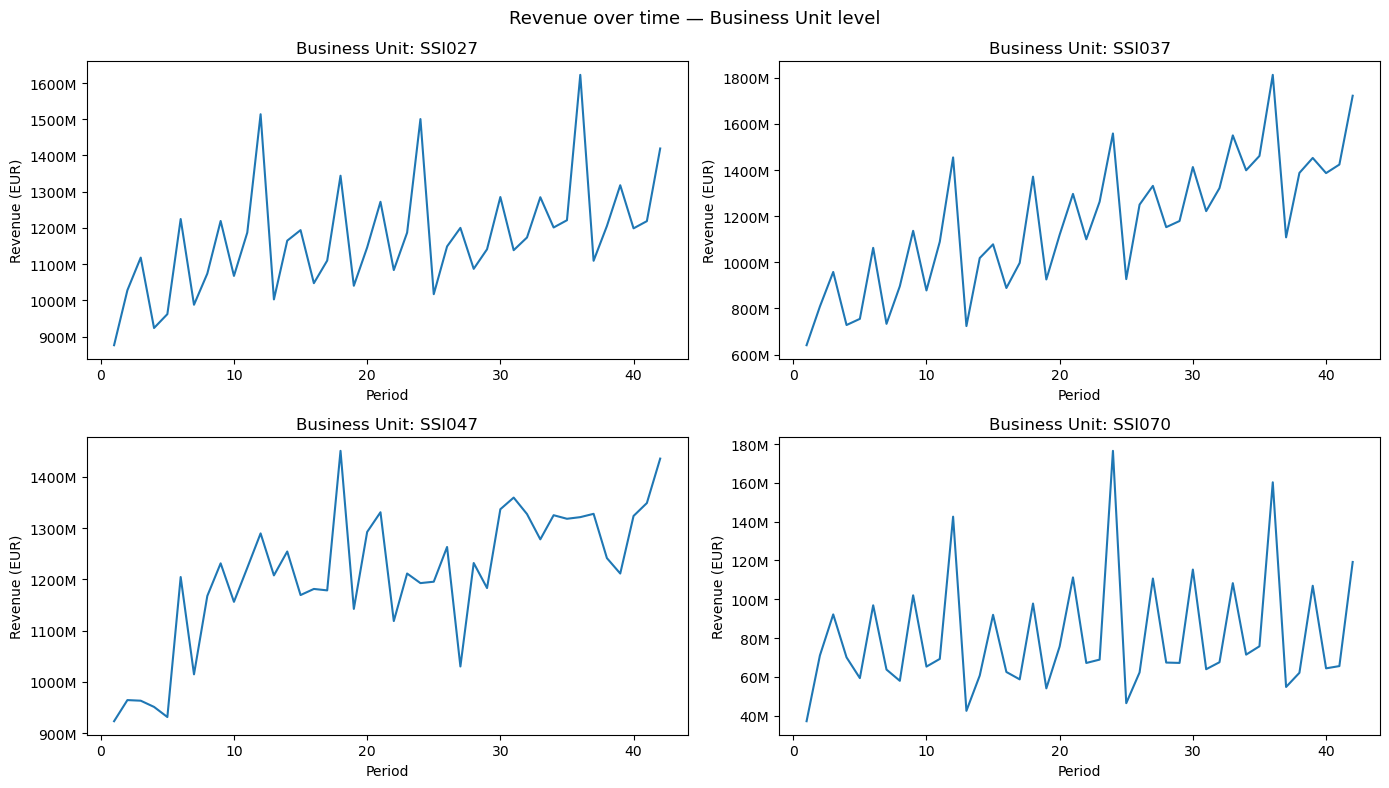

In [11]:
#revenue over time at BUSINESS UNIT level
bu_data = df_merged.groupby(['Period', 'Business_Unit'])['Revenue'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, bu in enumerate(sorted(bu_data['Business_Unit'].unique())):
    d = bu_data[bu_data['Business_Unit'] == bu]
    axes[i].plot(d['Period'], d['Revenue'])
    axes[i].set_title(f'Business Unit: {bu}')
    axes[i].set_xlabel('Period')
    axes[i].set_ylabel('Revenue (EUR)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('Revenue over time — Business Unit level', fontsize=13)
plt.tight_layout()
plt.show()

- All 4 BUs show a generally upward trend over the 42 periods, which is good — it means there's a learnable trend signal for the model
- SSI027 appears to be the largest BU by revenue. 
- Some BUs show quite volatile month-to-month swings which suggests either genuine business volatility or that some subsegments dominate and skew the total.

SSI027:

- Relatively flat trend compared to the other BUs — revenue oscillates mostly between 0.9B and 1.3B with no strong directional drift. The most stable of the four.
- The volatility pattern looks somewhat periodic — there may be a weak seasonal cycle here, but it's hard to confirm without STL.
- The spike around period 25 (~1.6B) stands out as a potential outlier worth investigating.

SSI037:

- The strongest and most consistent upward trend of all four BUs — revenue roughly triples from ~0.6B to ~1.8B over the window. This BU is driving a big part of the World-level trend you saw in the previous plot.
- Despite the trend, there's still meaningful period-to-period volatility, meaning the trend alone won't be enough to forecast this well — you need to capture the residual fluctuations too.

SSI047:

- A moderate upward trend, similar in shape to SSI037 but less steep. Revenue grows from ~0.9B to ~1.4B.
- Notably the smoothest of the four BUs — the swings between consecutive periods are smaller. This is likely your most forecastable BU and potentially a good anchor for the middle-out approach at the BU level.

SSI070:

- Note the y-axis is 1e8, not 1e9 — this BU is an order of magnitude smaller than the others. It contributes very little to World-level totals but will matter for subsegment granularity.
- Very high relative volatility — the swings are large relative to the mean. This is the noisiest and hardest to forecast BU.
- There's a possible slight upward trend but it's completely obscured by the noise.

Cross-BU takeaways relevant to your modeling:

- SSI037 and SSI047 have the clearest structure and should get the most sophisticated models at BU level — Prophet or SARIMA with trend.
- SSI027 is stable and well-suited for ETS or a simpler seasonal model.
- SSI070 is problematic — given its size and noise, errors here won't significantly impact World-level RMSE, but you should flag it. A simple mean or naïve seasonal model may outperform complex ones for this BU.
- The fact that BUs behave so differently from each other confirms that a single global model across all BUs would struggle — fitting separate models per BU is the right call.

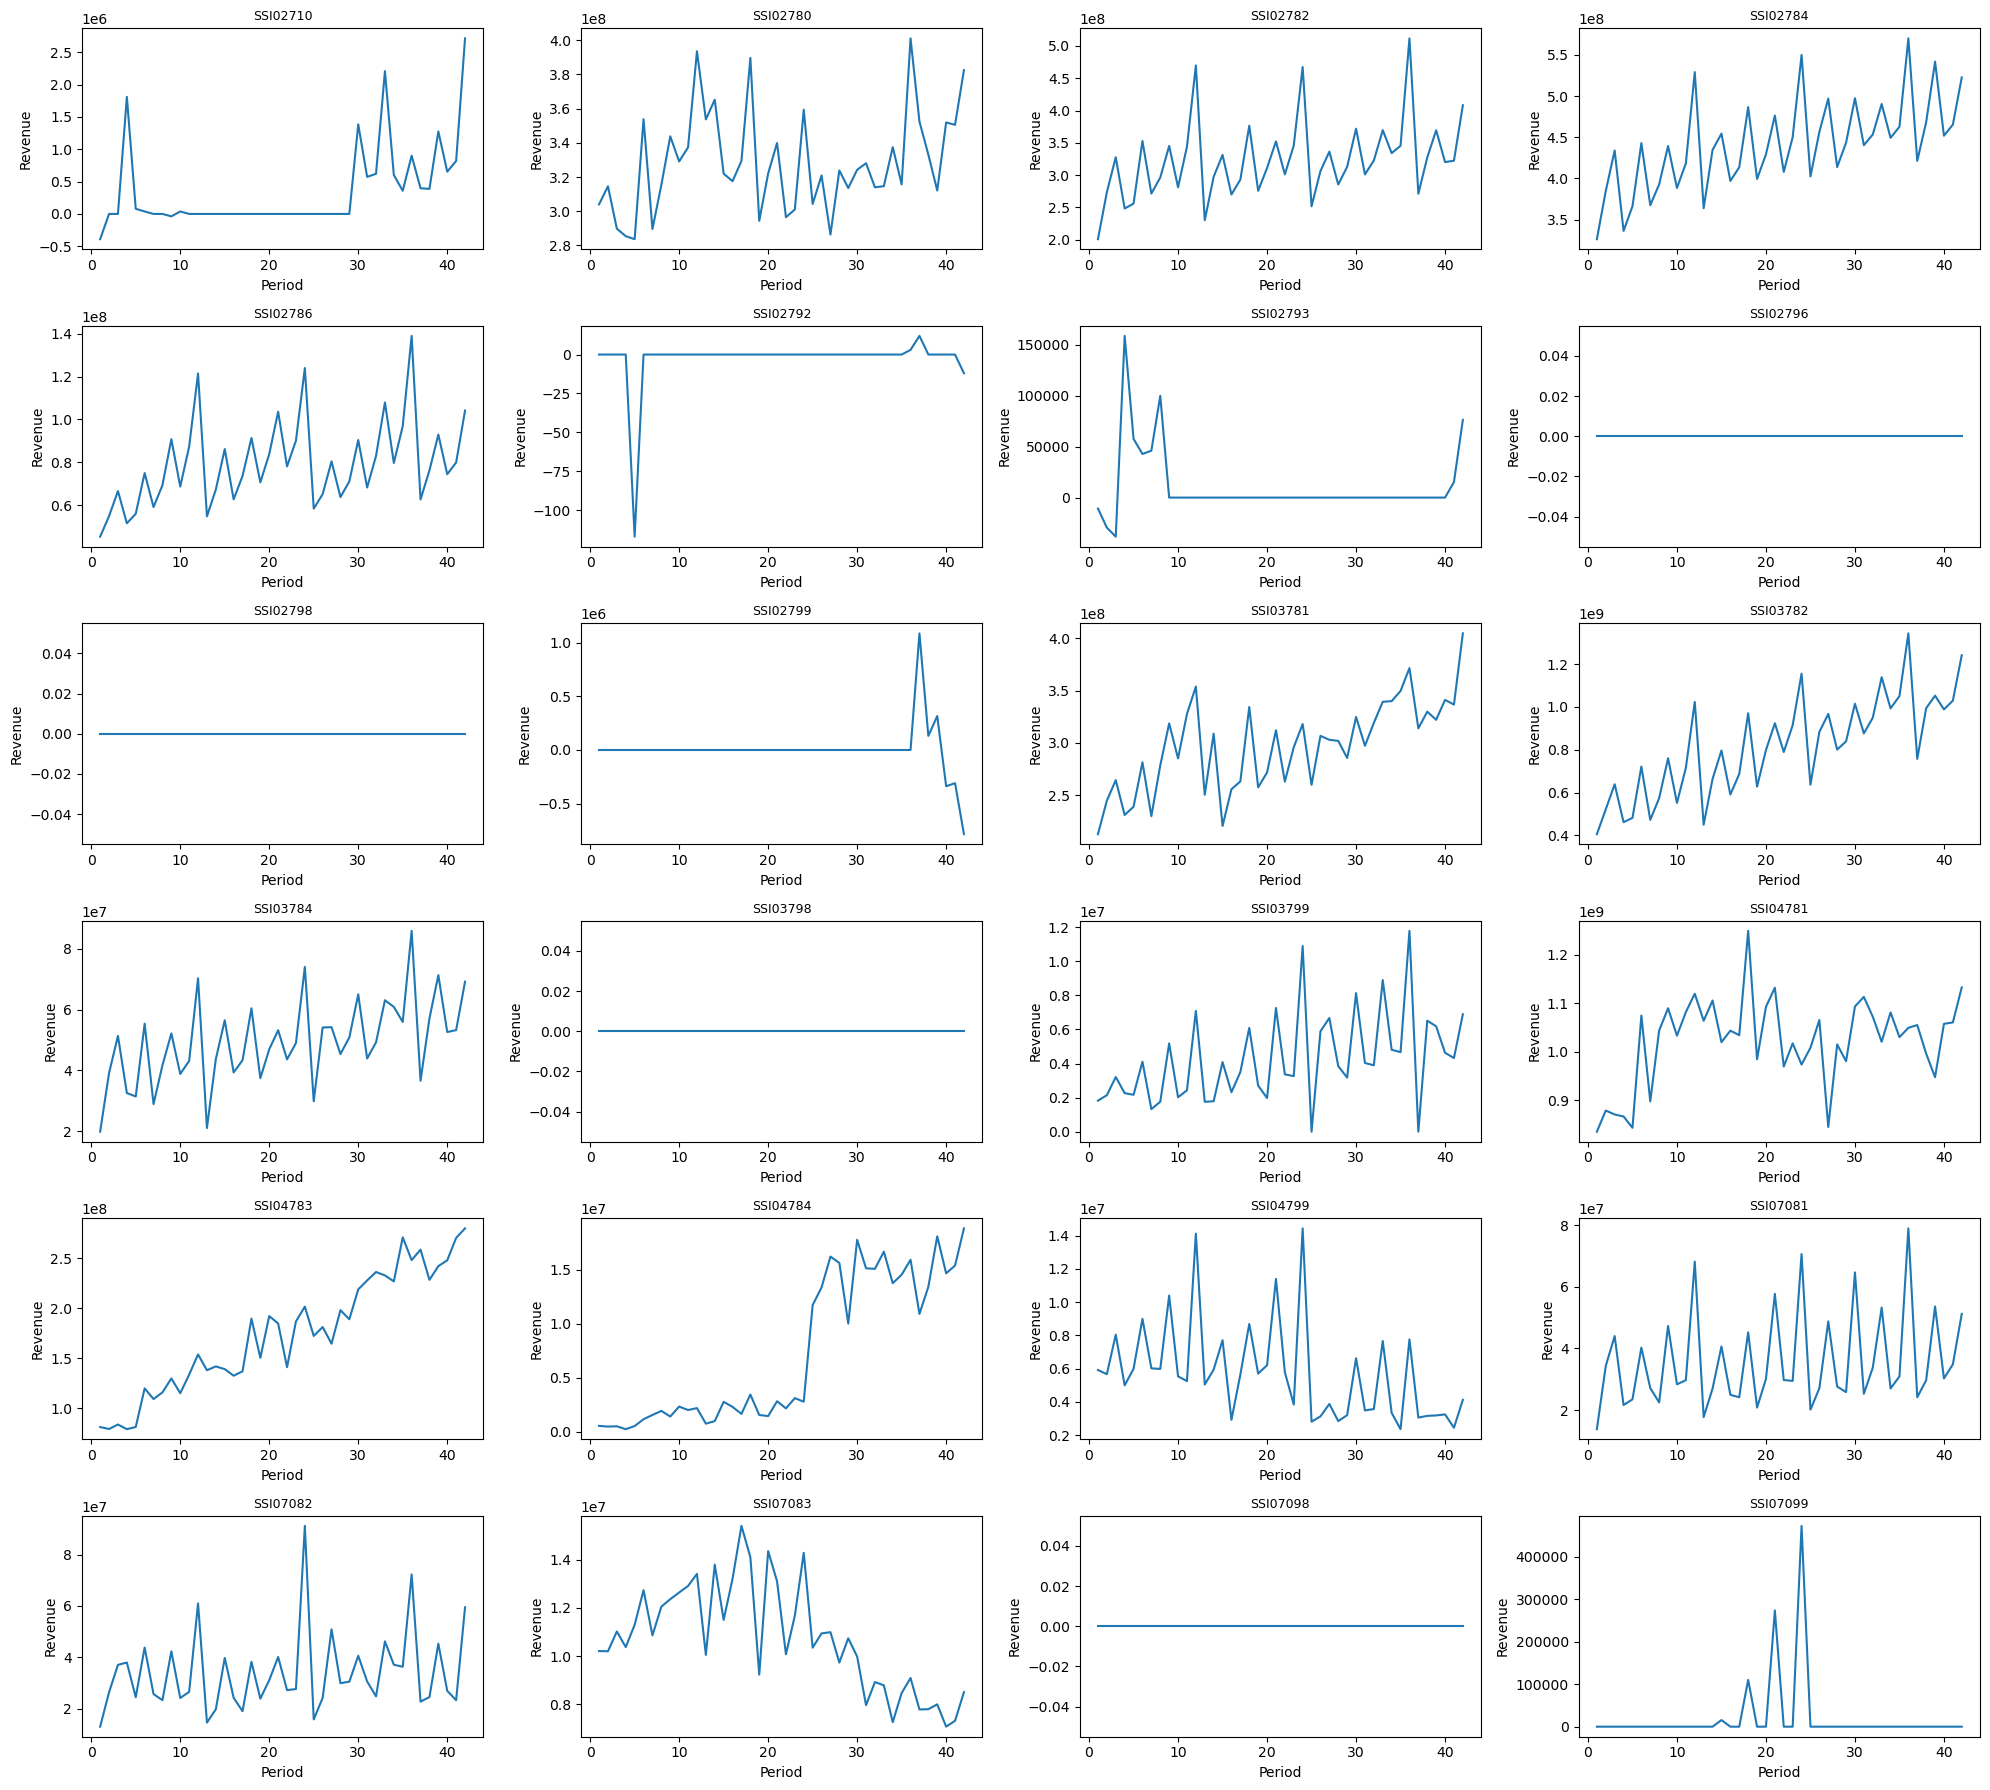

In [12]:
#revenue over time at SEGMENT level
segments = df_merged['Segment'].unique()

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 18))
axes = axes.flatten()

for i, seg in enumerate(sorted(segments)):
    seg_data = (
        df_merged[df_merged['Segment'] == seg]
        .groupby('Period')['Revenue']
        .sum()
        .reset_index()
    )
    axes[i].plot(seg_data['Period'], seg_data['Revenue'])
    axes[i].set_title(seg, fontsize=9)
    axes[i].set_xlabel('Period')
    axes[i].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

- Some segments are very stable and smooth — these will be easy to forecast. Others are extremely spiky or flat near zero for many periods — these are the problematic sparse ones we already identified. 
- The flat-near-zero segments are likely the ones with high sparsity from the chart.

Scale heterogeneity is extreme

- Y-axes range from 1e6 to 1e9 across segments — a 1000x difference in magnitude. This means a handful of large segments (SSI03782, SSI04781) will completely dominate any World-level error metric. Small segments could forecast terribly and barely affect your RMSE.

Several segments are essentially flat-zero

- SSI02796, SSI02798, SSI03798, SSI07098 show near-zero values throughout — these are either inactive, discontinued, or placeholder segments. They will cause problems in quota/distribution models (division by near-zero) and should be excluded or handled separately.

Structural breaks are common

- SSI02792 has a massive negative spike early on then flatlines — looks like a one-time accounting correction, not a real revenue pattern.
- SSI02793 has very high early values then drops to near-zero and stays there — a discontinued product line or restructuring event. Modeling this as a continuous series makes no sense.
- SSI02799 and SSI04784 show sudden jumps from zero to active mid-series — new product launches. These series have effectively fewer than 42 usable periods.

Two dominant behavior archetypes

- About half the segments show a clear upward trend with moderate volatility (SSI02784, SSI03781, SSI03782, SSI04781, SSI04783) — these are your well-behaved, forecastable segments and should be your middle-out anchor candidates.
- The other half show high spikiness with no clear trend (SSI02780, SSI02782, SSI02786, SSI03784, SSI07081) — these are harder to model and will likely need simpler approaches like ETS or seasonal naïve.

Seasonality is visible in several segments

- Segments like SSI02784, SSI02786, SSI03781, SSI04783 show fairly regular oscillations on top of their trend — this is promising and suggests STL decomposition will find a usable seasonal component at the segment level.
- The spike-dominated segments (SSI07081, SSI07082) look more like intermittent demand than seasonal patterns — different modeling treatment needed.

Practical implications for your pipeline:

- You likely want to exclude or separately handle the flat-zero and structurally broken segments before fitting any models.
- The middle-out anchor should come from the well-behaved trending segments — they have the richest exploitable structure.
- Consider splitting segments into two groups — "well-behaved" and "problematic" — and applying different model strategies to each rather than one uniform approach.


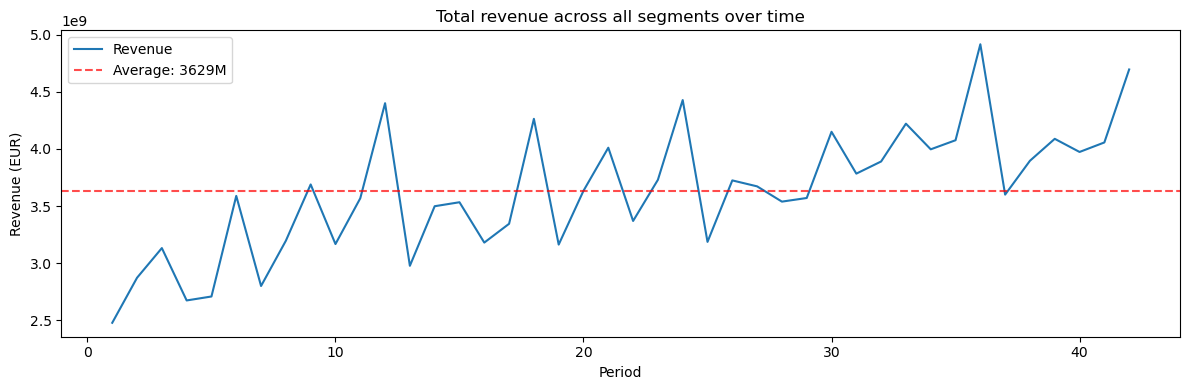

In [18]:
total_revenue = df_merged.groupby('Period')['Revenue'].sum().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(total_revenue['Period'], total_revenue['Revenue'], label='Revenue')
plt.axhline(total_revenue['Revenue'].mean(), color='red', linestyle='--', 
            alpha=0.7, label=f'Average: {total_revenue["Revenue"].mean()/1e6:.0f}M')
plt.title('Total revenue across all segments over time')
plt.xlabel('Period')
plt.ylabel('Revenue (EUR)')
plt.legend()
plt.tight_layout()
plt.show()

- There's a clear upward trend overall with some cyclical variation. This is very useful — it confirms a trend component exists that SARIMA and Prophet can model well.

Revenue:

- Clear upward trend overall — the series goes from ~2.5B in early periods to ~4.7B by period 42, meaning the World-level revenue has roughly doubled over the data window. This is important — your models need to capture this trend explicitly.
- The series is not stationary — the mean is visibly drifting upward, which the ADF test will likely confirm. You'll need to either detrend or difference before feeding into certain models.
- There's notable volatility around the trend — big swings up and down between consecutive periods. This suggests either genuine business cyclicality or that some periods aggregate differently (e.g., fiscal quarter-end effects).
- The red mean line sits well below the recent periods, further confirming the trend — the mean is being pulled down by the early low-value periods and is not a good summary statistic for this series.

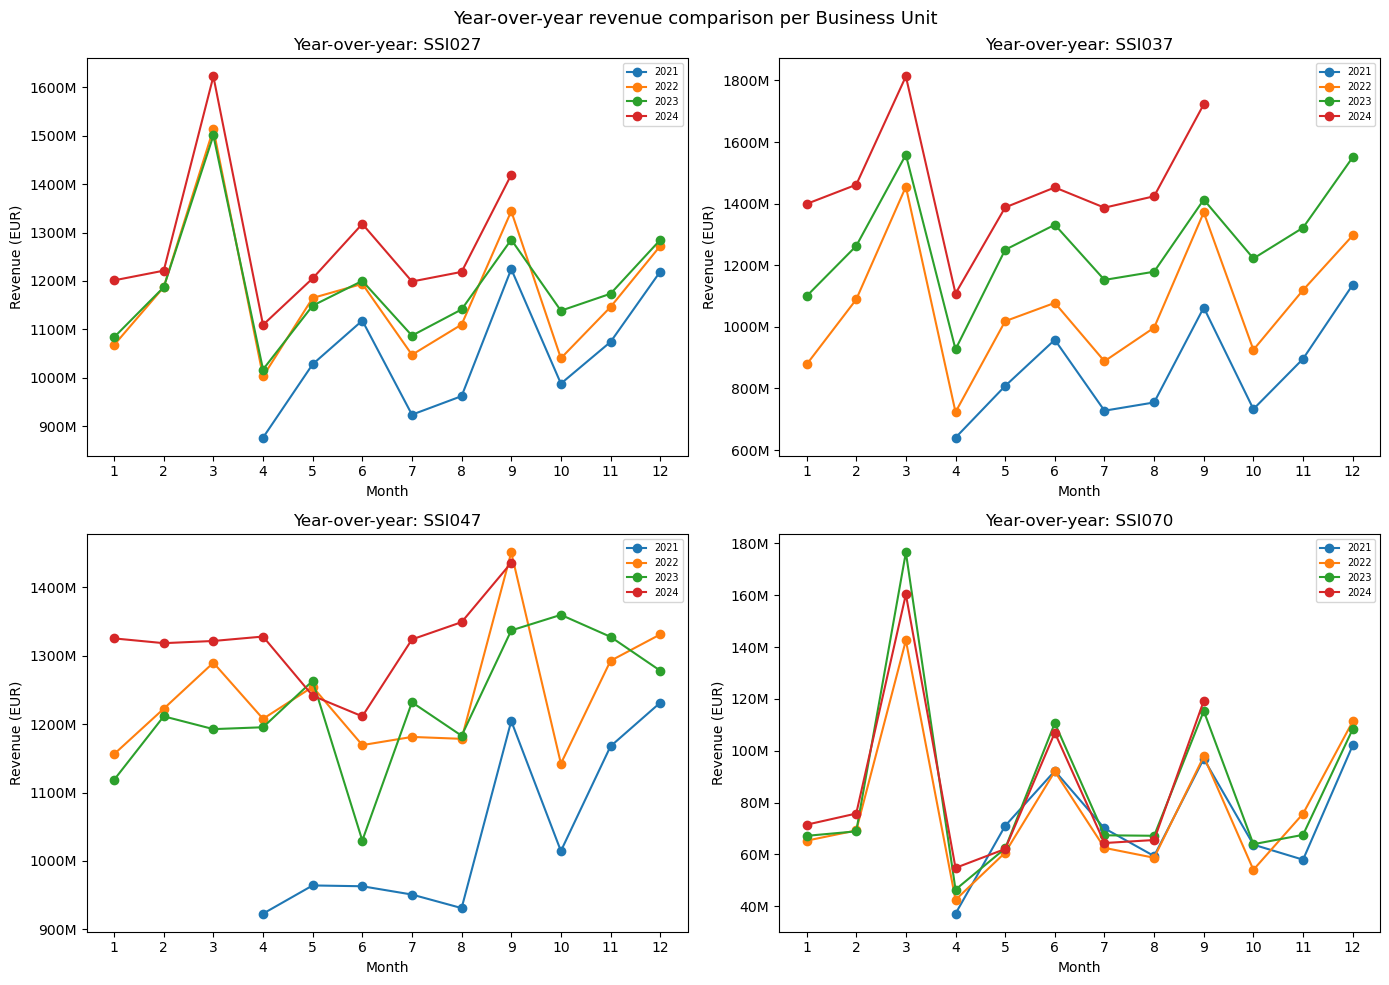

In [24]:
#Year-over-year comparison per BU
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.month
df_merged['Year']  = pd.to_datetime(df_merged['Date']).dt.year

bu_list = sorted(df_merged['Business_Unit'].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, bu in enumerate(bu_list):
    d = df_merged[df_merged['Business_Unit'] == bu]
    yoy = d.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
    for year in sorted(yoy['Year'].unique()):
        y_data = yoy[yoy['Year'] == year]
        axes[i].plot(y_data['Month'], y_data['Revenue'], marker='o', label=str(year))
    axes[i].set_title(f'Year-over-year: {bu}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Revenue (EUR)')
    axes[i].set_xticks(range(1, 13))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    axes[i].legend(fontsize=7)
plt.suptitle('Year-over-year revenue comparison per Business Unit', fontsize=13)
plt.tight_layout()
plt.show()

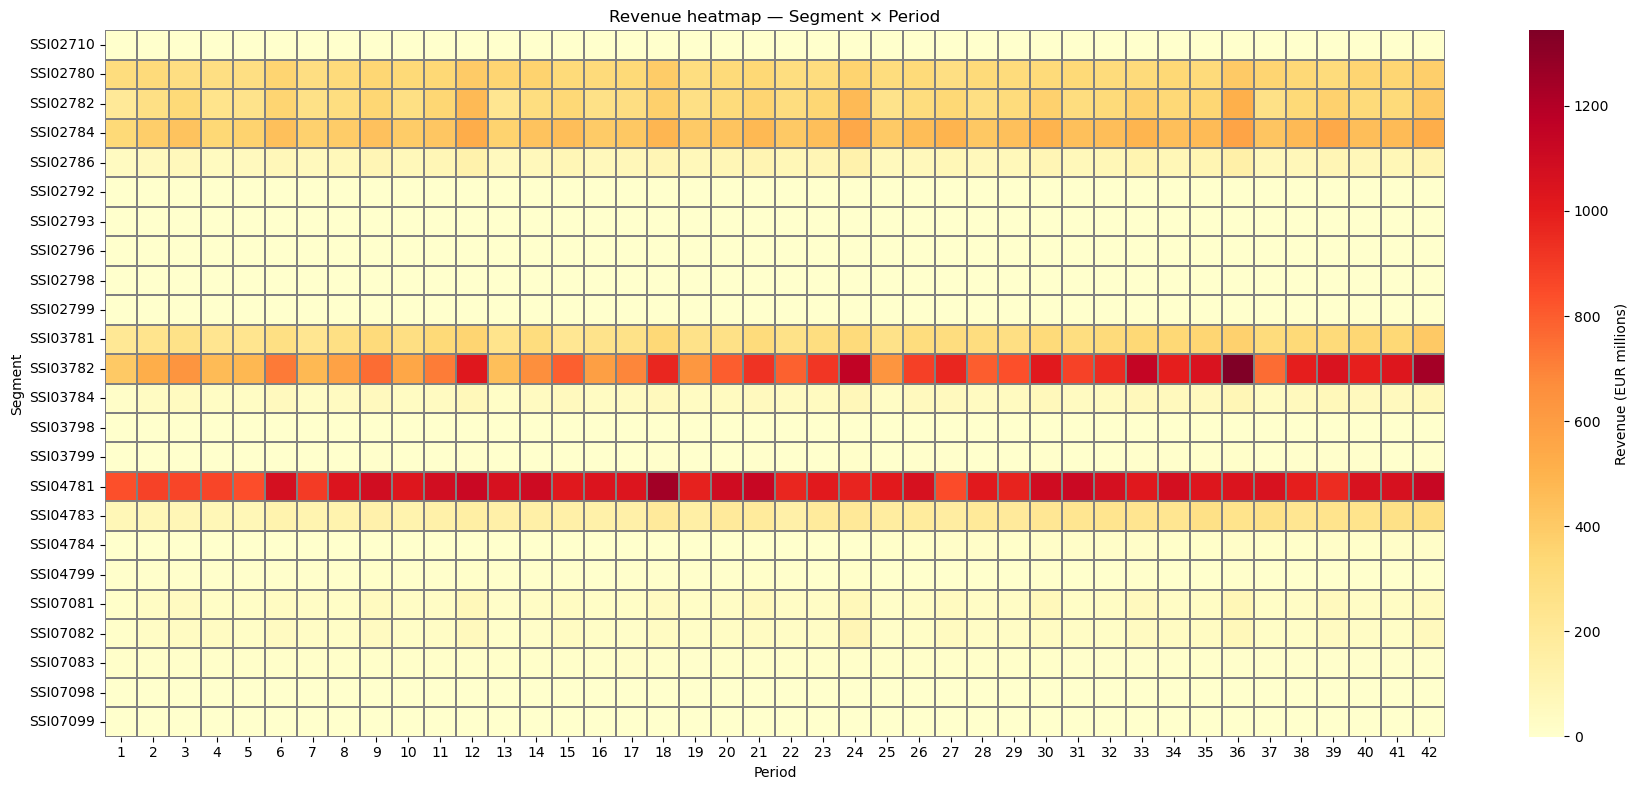

In [25]:
#Heatmap of revenue by segment × period
heatmap_data = (
    seg_data.pivot(index='Segment', columns='Period', values='Revenue')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    heatmap_data / 1e6,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Revenue (EUR millions)'}
)
ax.set_title('Revenue heatmap — Segment × Period')
ax.set_xlabel('Period')
ax.set_ylabel('Segment')
plt.tight_layout()
plt.show()

#### 3.2.2. Checking Seasonality

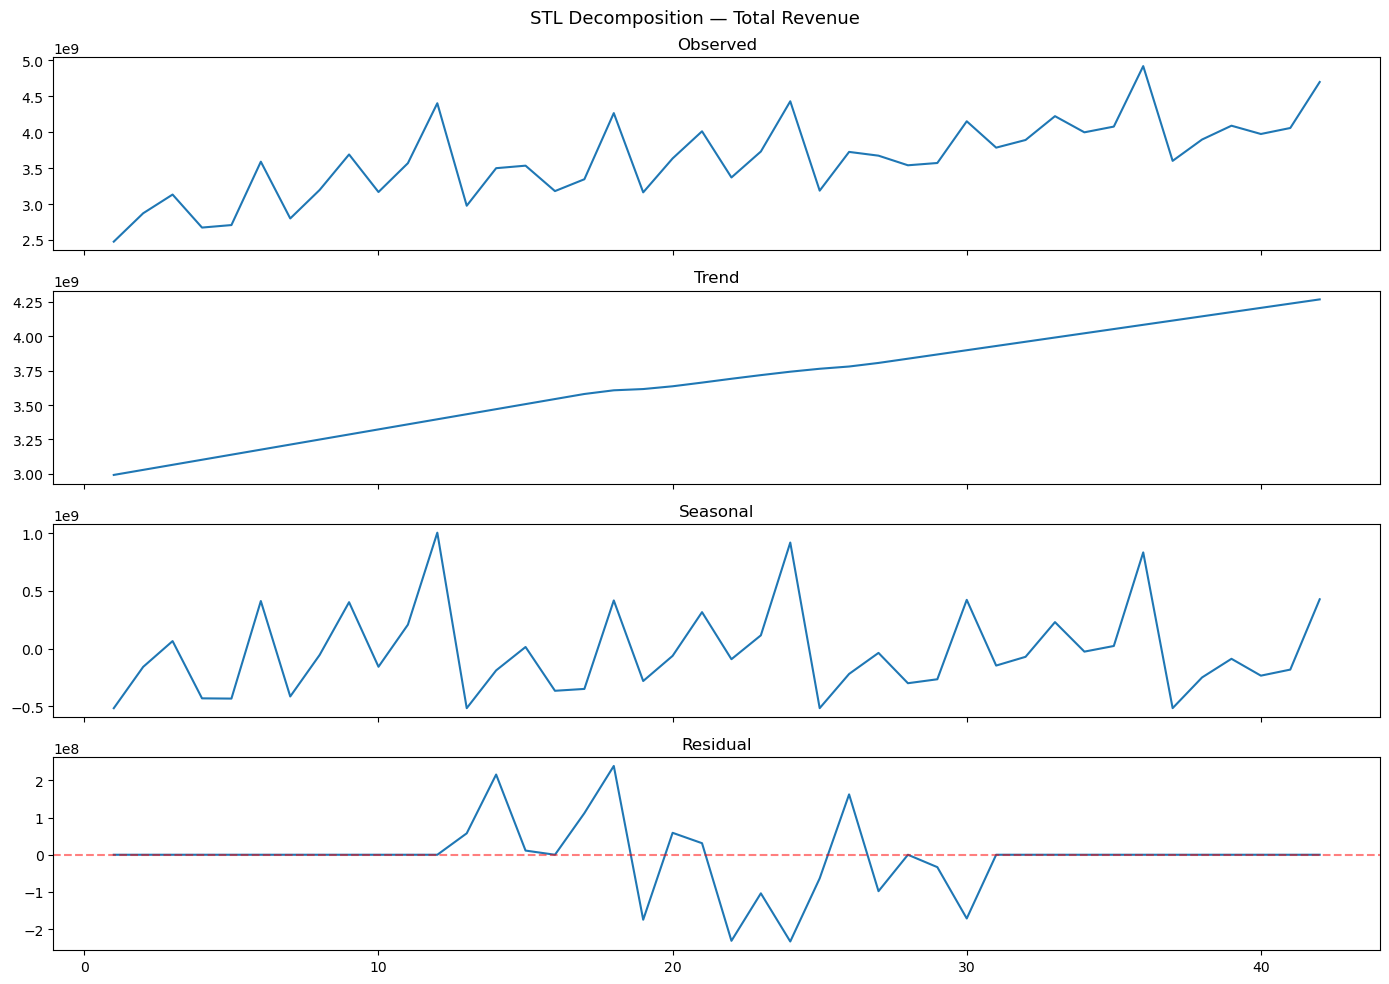

In [20]:
from statsmodels.tsa.seasonal import STL

total_revenue = df_merged.groupby('Period')['Revenue'].sum().reset_index()

stl = STL(total_revenue['Revenue'], period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(total_revenue['Period'], total_revenue['Revenue'])
axes[0].set_title('Observed')
axes[1].plot(total_revenue['Period'], result.trend)
axes[1].set_title('Trend')
axes[2].plot(total_revenue['Period'], result.seasonal)
axes[2].set_title('Seasonal')
axes[3].plot(total_revenue['Period'], result.resid)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[3].set_title('Residual')
plt.suptitle('STL Decomposition — Total Revenue', fontsize=13)
plt.tight_layout()
plt.show()

Trend

- Almost perfectly linear upward trend from ~3.0B to ~4.3B over the 42 periods. This is the dominant component of the series and your models must capture it — any model that assumes a stationary mean will underperform significantly.
- The linearity is good news — a simple linear trend term or first-differencing will be sufficient. You don't need a complex nonlinear trend model.

Seasonal

- Seasonality is real and strong — the seasonal component oscillates between roughly -0.5B and +1.0B, which is a swing of ~1.5B on a series whose total range is ~2.5B. That means seasonality explains a very large share of the period-to-period variation you saw in the observed plot.
- The pattern is not perfectly regular — some seasonal peaks are much larger than others (e.g., the spike around period 13–14 and again around period 25). This asymmetry suggests the seasonal amplitude may be growing with the trend, which would mean a multiplicative rather than additive seasonality model could fit better. Worth testing both.
- With only ~3.5 full seasonal cycles in 42 periods, the STL is doing its best but the seasonal estimate has uncertainty — don't over-rely on the exact shape.

Residual

- The residuals are on the order of 1e8, while the observed series is 1e9 — so residuals are roughly 10% of the signal. That's reasonably small, meaning the trend + seasonal components together explain ~90% of the variance. Good.
- However the residuals are not pure white noise — there's a cluster of large residuals around periods 15–25, which coincides with what appeared to be higher volatility in the observed plot. This could be a real business event (COVID disruption period) or a sign that the seasonal pattern shifted mid-series.
- The residuals settle down to near-zero after period 30, which is actually encouraging for forecasting — the most recent periods are the cleanest.

Overall STL takeaway for your pipeline:

- Confirmed: trend + seasonality are both worth modeling explicitly — neither can be ignored.
- The World level is well-behaved enough that Prophet (which handles linear trend + Fourier seasonality natively) or Holt-Winters with additive/multiplicative seasonality will work well here.
- The residual cluster in the middle periods is worth flagging — if those correspond to COVID years (roughly 2021–2022 given your date range), you may want to add a dummy regressor for that window to prevent the model from treating it as a seasonal pattern.

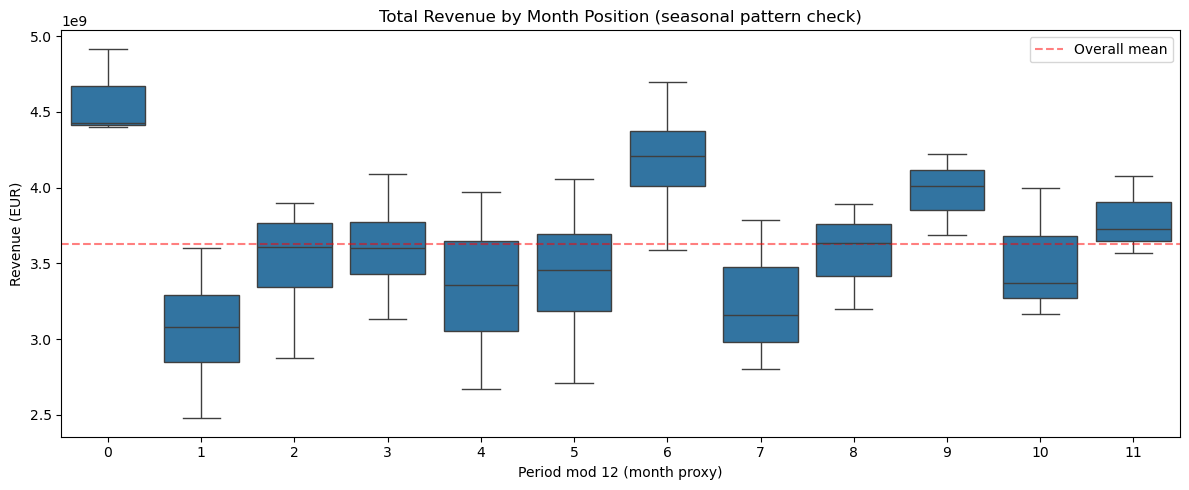

In [19]:
total_revenue['month_pos'] = total_revenue['Period'] % 12

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=total_revenue, x='month_pos', y='Revenue', ax=ax)
ax.axhline(total_revenue['Revenue'].mean(), color='red', linestyle='--', 
           alpha=0.5, label='Overall mean')
ax.set_title('Total Revenue by Month Position (seasonal pattern check)')
ax.set_xlabel('Period mod 12 (month proxy)')
ax.set_ylabel('Revenue (EUR)')
ax.legend()
plt.tight_layout()
plt.show()

The seasonal pattern that emerges

Position 0 is clearly the highest revenue month — median ~4.6B, well above the overall mean. This corresponds to one specific calendar month that consistently outperforms.
Position 1 is the lowest — median ~3.1B, the furthest below the mean. The drop from position 0 to position 1 is the sharpest transition in the entire cycle.
Position 6 is a secondary peak — median ~4.2B, the second highest position. This suggests a bimodal seasonal pattern with peaks roughly 6 months apart, which is common in B2B industrial sales (two strong booking/delivery cycles per year).
Positions 7 is a secondary trough, mirroring position 1 on the other side of the year.
The overall shape roughly follows: high → low → medium → medium → medium → high → low → medium — a wave with two cycles per year.

The caveat — this is a proxy, not exact months

Because your periods are anonymized and you're using period mod 12 as a month proxy, position 0 may not actually correspond to January. The relative pattern is valid but you cannot label these as specific calendar months without mapping back through the date column you have. You should do that mapping — df_merged.groupby('Period')['Date'].first() will give you the actual calendar month for each period position, which will make this plot interpretable in business terms.

Box widths reveal trend contamination

The boxes at position 0 and 6 are very tight (low variance across the ~3 observations per position) — meaning those peaks are consistent year over year, which is strong evidence of genuine seasonality.
Positions 2–5 and 8–11 have wider boxes — more variance, meaning those middle months are less predictable and more influenced by the underlying trend or random shocks.
This is actually a known artifact of doing this analysis on a trending series — the upward trend means later-year observations of each month position are systematically higher than earlier ones, inflating box width. Ideally you'd detrend first before making this plot, but the pattern is clear enough to trust regardless.

Modeling implications:

The bimodal seasonal pattern with a period-6 secondary peak is important to communicate to your model. A standard annual seasonality assumption (period=12) will capture it, but make sure your seasonal period parameter is set to 12 and not a shorter cycle.
The consistency of the peaks at positions 0 and 6 means these are the most forecastable points in the cycle — your model should nail those. If it doesn't, something is wrong with the seasonal specification.
Since you have the actual Date column, map the positions to real months before finalizing your EDA — knowing whether the peak is September vs December is meaningful for the business stakeholder presentation.

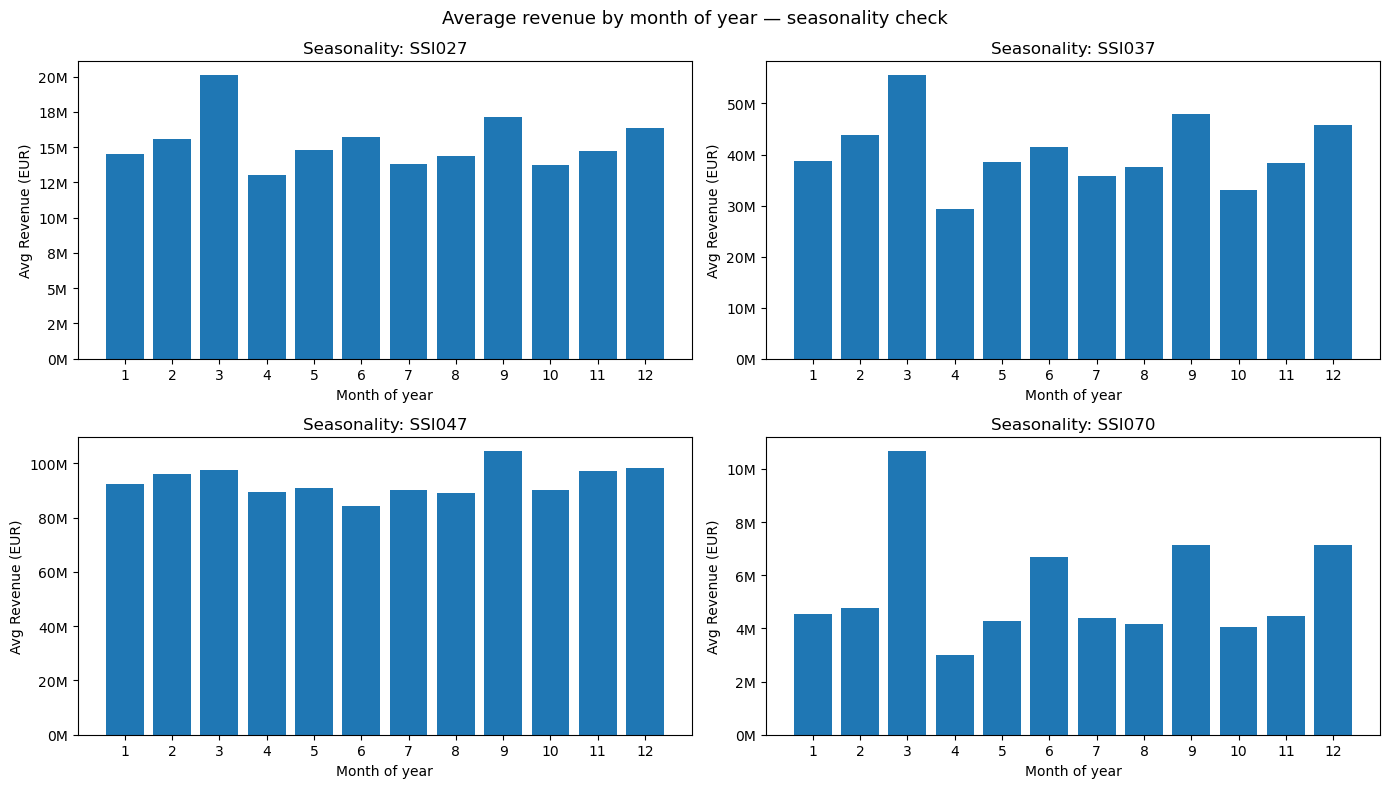

In [14]:
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.month

seasonality = (
    df_merged.groupby(['Business_Unit', 'Month'])['Revenue']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, bu in enumerate(sorted(df_merged['Business_Unit'].unique())):
    d = seasonality[seasonality['Business_Unit'] == bu]
    axes[i].bar(d['Month'], d['Revenue'])
    axes[i].set_title(f'Seasonality: {bu}')
    axes[i].set_xlabel('Month of year')
    axes[i].set_ylabel('Avg Revenue (EUR)')
    axes[i].set_xticks(range(1, 13))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('Average revenue by month of year — seasonality check', fontsize=13)
plt.tight_layout()
plt.show()

- There seems to be some seasonal pattern — certain months consistently show higher revenue than others. This is important because it confirms that including a month-of-year feature will help our model to make good predictions. 
- Month 3 (March) is usually the month with higher revenue in all business units except for SSI047. Moreover, September and December also show to be relevant in terms of revenue. 

#### 3.2.3. Hierarchy Proportions

In [15]:
seg_totals = (
    df_merged.groupby(['Period', 'Segment'])['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'Seg_Revenue'})
)

df_prop = df_merged.merge(seg_totals, on=['Period', 'Segment'], how='left')
df_prop['Proportion'] = df_prop['Revenue'] / df_prop['Seg_Revenue'].replace(0, np.nan)

avg_proportions = (
    df_prop.groupby(['Business_Unit', 'Segment', 'Subsegment'])['Proportion']
    .mean()
    .reset_index()
    .rename(columns={'Proportion': 'Avg_Proportion'})
    .sort_values(['Business_Unit', 'Segment', 'Avg_Proportion'], ascending=[True, True, False])
)

# display ALL proportions grouped by segment
pd.set_option('display.max_rows', None)
print("=== SUBSEGMENT PROPORTIONS WITHIN EACH SEGMENT ===")
print(avg_proportions.to_string(index=False))
pd.reset_option('display.max_rows')

=== SUBSEGMENT PROPORTIONS WITHIN EACH SEGMENT ===
Business_Unit  Segment Subsegment  Avg_Proportion
       SSI027 SSI02710   SSI02710    6.905476e-01
       SSI027 SSI02710 SSI0271002    2.884138e-01
       SSI027 SSI02710 SSI0271099    2.092467e-02
       SSI027 SSI02710 SSI0271006    1.139462e-04
       SSI027 SSI02710 SSI0271004    0.000000e+00
       SSI027 SSI02780 SSI0278002    6.748577e-01
       SSI027 SSI02780 SSI0278004    3.210052e-01
       SSI027 SSI02780 SSI0278006    2.193300e-03
       SSI027 SSI02780 SSI0278099    1.943820e-03
       SSI027 SSI02780   SSI02780   -1.504791e-08
       SSI027 SSI02782 SSI0278202    4.977674e-01
       SSI027 SSI02782 SSI0278204    2.966831e-01
       SSI027 SSI02782 SSI0278206    1.825339e-01
       SSI027 SSI02782 SSI0278208    1.999374e-02
       SSI027 SSI02782   SSI02782    1.418537e-03
       SSI027 SSI02782 SSI0278210    7.780190e-04
       SSI027 SSI02782 SSI0278212    4.922482e-04
       SSI027 SSI02782 SSI0278214    1.692429e-04

In [ ]:
#Subsegment proportion stability over time
seg_totals = (
    df_merged.groupby(['Period', 'Segment'])['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'Seg_Revenue'})
)
df_prop = df_merged.merge(seg_totals, on=['Period', 'Segment'], how='left')
df_prop['Proportion'] = df_prop['Revenue'] / df_prop['Seg_Revenue'].replace(0, np.nan)

# plot proportion stability for each segment
for seg in segments:
    seg_sub = df_prop[df_prop['Segment'] == seg]
    subsegments = seg_sub['Subsegment'].unique()

    if len(subsegments) <= 1:
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    for sub in subsegments:
        d = seg_sub[seg_sub['Subsegment'] == sub].sort_values('Period')
        ax.plot(d['Period'], d['Proportion'], label=sub, marker='o', markersize=3)
    ax.set_title(f'Proportion stability over time — Segment {seg}')
    ax.set_xlabel('Period')
    ax.set_ylabel('Share of segment revenue')
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.tight_layout()
    plt.show()

NameError: name 'segments' is not defined

#### 3.2.4. Checking Sparsity — zero percentage per subsegment

C:\Users\martr\AppData\Local\Temp\ipykernel_32136\3953261700.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Revenue'] == 0).sum() / len(x) * 100)


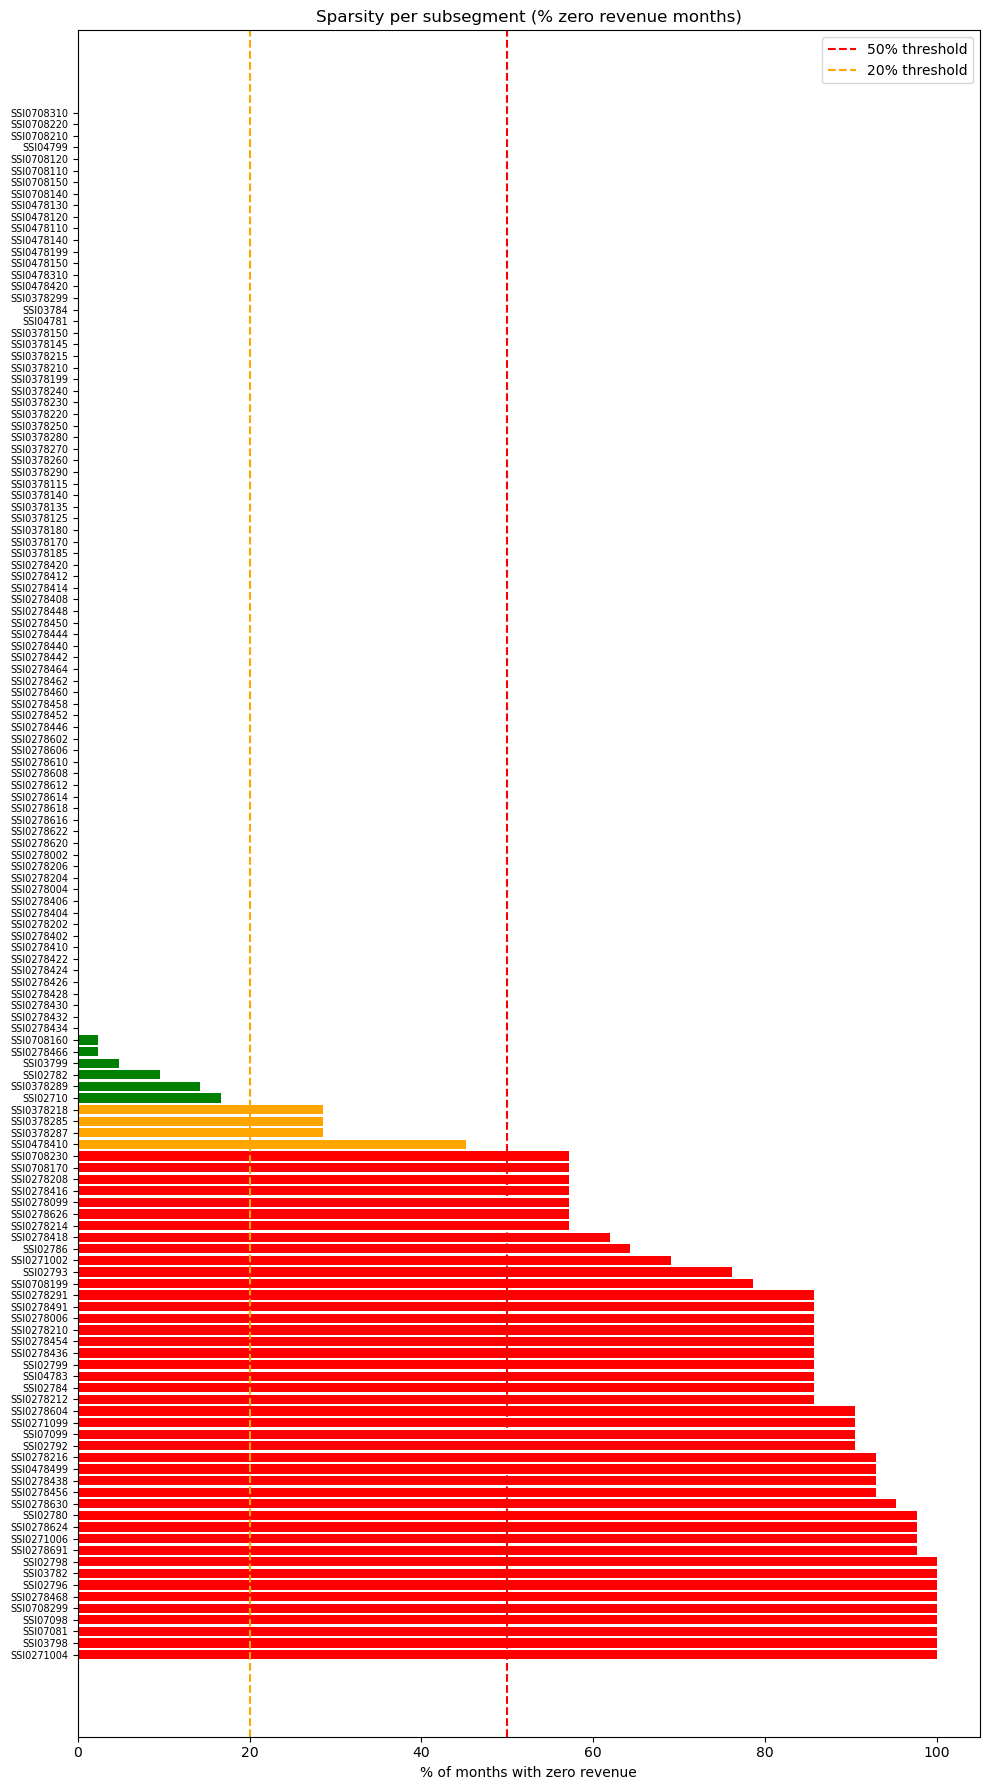

In [18]:
zero_pct = (
    df_merged.groupby(['Segment', 'Subsegment'])
    .apply(lambda x: (x['Revenue'] == 0).sum() / len(x) * 100)
    .reset_index()
    .rename(columns={0: 'Zero_Pct'})
    .sort_values('Zero_Pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 18))
colors = ['red' if z > 50 else 'orange' if z > 20 else 'green' for z in zero_pct['Zero_Pct']]
ax.barh(zero_pct['Subsegment'], zero_pct['Zero_Pct'], color=colors)
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.axvline(20, color='orange', linestyle='--', label='20% threshold')
ax.set_xlabel('% of months with zero revenue')
ax.set_title('Sparsity per subsegment (% zero revenue months)')
ax.tick_params(axis='y', labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

- A large proportion of subsegments are red (>50% zero months). This is a critical finding — it means many subsegments are too sparse to model individually with any reliability. 

In [19]:
print("\nSubsegments with >50% zero months (consider excluding from model):")
print(zero_pct[zero_pct['Zero_Pct'] > 50][['Segment', 'Subsegment', 'Zero_Pct']].to_string(index=False))


Subsegments with >50% zero months (consider excluding from model):
 Segment Subsegment   Zero_Pct
SSI02710 SSI0271004 100.000000
SSI03798   SSI03798 100.000000
SSI07081   SSI07081 100.000000
SSI07098   SSI07098 100.000000
SSI07082 SSI0708299 100.000000
SSI02784 SSI0278468 100.000000
SSI02796   SSI02796 100.000000
SSI03782   SSI03782 100.000000
SSI02798   SSI02798 100.000000
SSI02786 SSI0278691  97.619048
SSI02710 SSI0271006  97.619048
SSI02786 SSI0278624  97.619048
SSI02780   SSI02780  97.619048
SSI02786 SSI0278630  95.238095
SSI02784 SSI0278456  92.857143
SSI02784 SSI0278438  92.857143
SSI04784 SSI0478499  92.857143
SSI02782 SSI0278216  92.857143
SSI02792   SSI02792  90.476190
SSI07099   SSI07099  90.476190
SSI02710 SSI0271099  90.476190
SSI02786 SSI0278604  90.476190
SSI02782 SSI0278212  85.714286
SSI02784   SSI02784  85.714286
SSI04783   SSI04783  85.714286
SSI02799   SSI02799  85.714286
SSI02784 SSI0278436  85.714286
SSI02784 SSI0278454  85.714286
SSI02782 SSI0278210  85.714286
SS

#### 3.2.5. Correlation between Market Variables and Total Revenue


=== TOP 20 MARKET VARIABLES CORRELATED WITH TOTAL REVENUE ===
                     Market_Variable  Abs_Correlation
                     Switzerland_GDP         0.738449
                   United_States_GDP         0.730418
         Italy_GDP_from_Construction         0.719797
                  United_Kingdom_GDP         0.718634
                 China_Interest_Rate         0.706348
       Germany_GDP_from_Construction         0.680555
                           Italy_GDP         0.680211
               United_States_Exports         0.673707
        United_Kingdom_Interest_Rate         0.662412
United_Kingdom_GDP_from_Construction         0.653288
                       Japan_Exports         0.643316
         United_States_Interest_Rate         0.635619
                         Germany_GDP         0.631302
                           China_GDP         0.628168
                France_Interest_Rate         0.621659
               Germany_Interest_Rate         0.621659
                 It

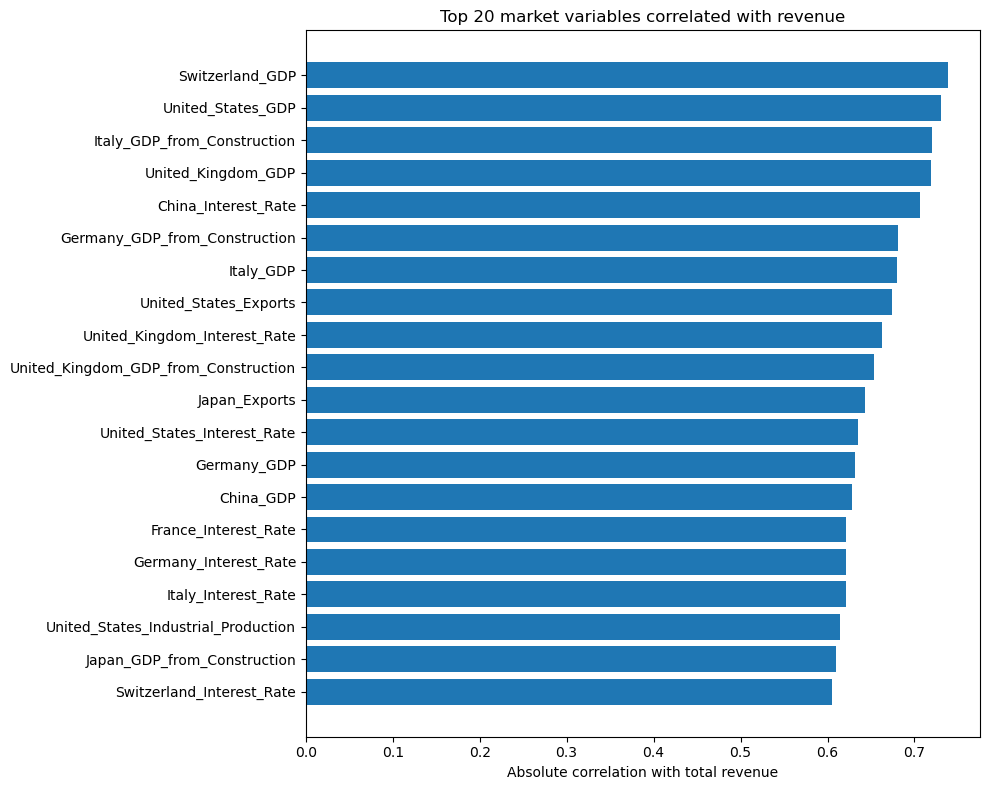

In [ ]:
market_cols = [c for c in df_merged.columns if any(
    c.startswith(country) for country in
    ['Germany', 'France', 'China', 'Italy', 'Japan',
     'Switzerland', 'United_Kingdom', 'United_States']
)]

total_rev_period = df_merged.groupby('Period')['Revenue'].sum().reset_index()
market_period    = df_merged.groupby('Period')[market_cols].mean().reset_index()
corr_df          = total_rev_period.merge(market_period, on='Period')

correlations = (
    corr_df[market_cols]
    .corrwith(corr_df['Revenue'])
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
correlations.columns = ['Market_Variable', 'Abs_Correlation']

print("\n=== TOP 20 MARKET VARIABLES CORRELATED WITH TOTAL REVENUE ===")
print(correlations.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = correlations.head(20)
ax.barh(top20['Market_Variable'], top20['Abs_Correlation'])
ax.set_xlabel('Absolute correlation with total revenue')
ax.set_title('Top 20 market variables correlated with revenue')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

- GDP variables dominate the top correlations, which makes economic sense — Siemens infrastructure products correlate with economic activity. However, it is important to note that we forward-filled the GDP columns, so these correlations might be slightly inflated. 
- Interest rates also appear strongly, which makes sense for capital-intensive industrial products. 

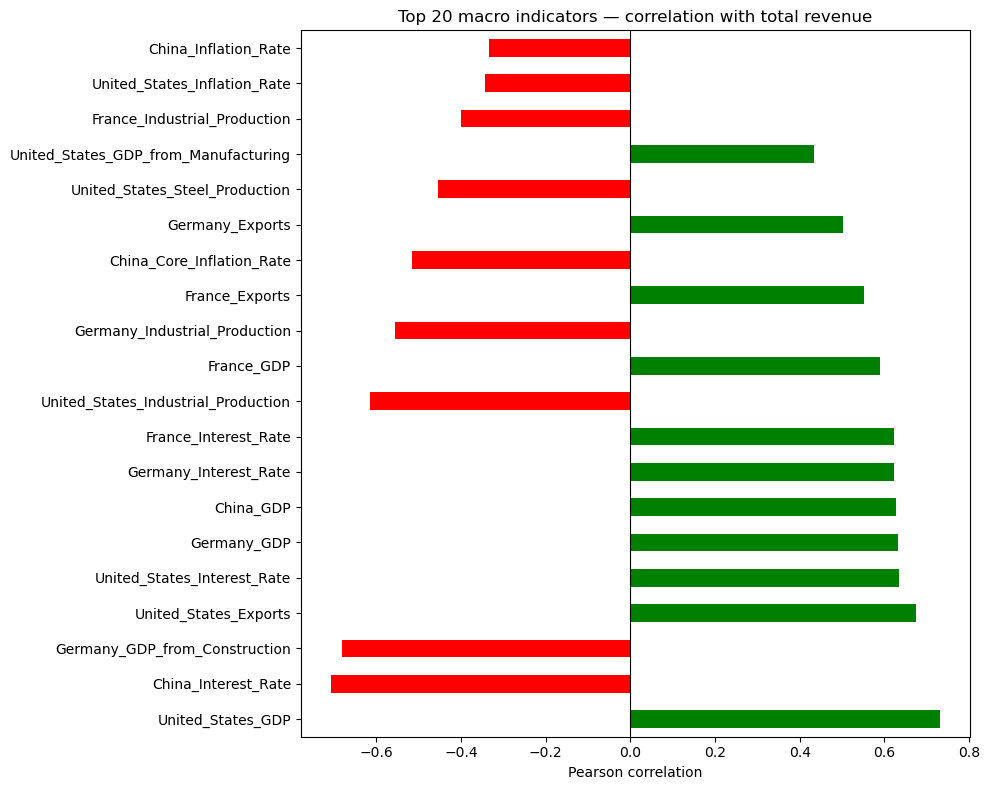

In [22]:
macro_cols = [c for c in df_merged.columns if any(
    c.startswith(x) for x in ['Germany', 'China', 'United_States', 'France']
)]

macro_df = df_merged.groupby('Period')[macro_cols].mean()
macro_df['Revenue'] = total_revenue.set_index('Period')['Revenue']

corr_with_revenue = (
    macro_df.corr()['Revenue']
    .drop('Revenue')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 8))
corr_with_revenue.head(20).plot(
    kind='barh',
    color=['green' if x > 0 else 'red' for x in corr_with_revenue.head(20)]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 macro indicators — correlation with total revenue')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

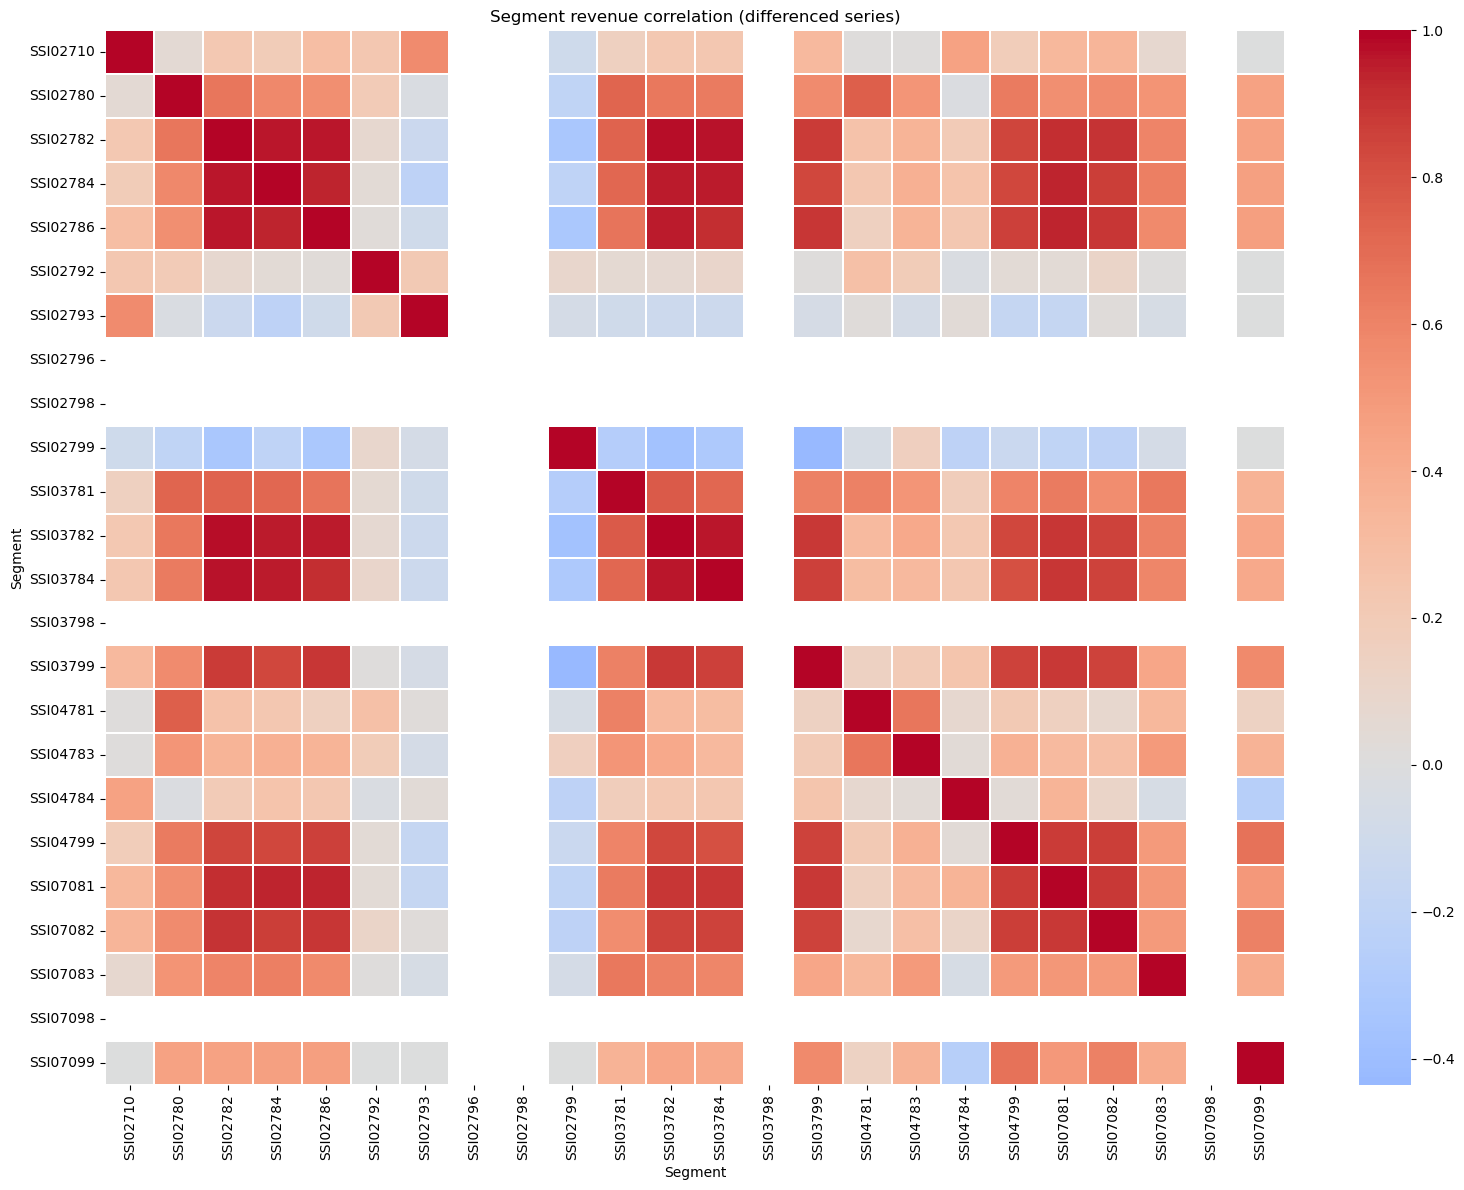

In [23]:
seg_data = df_merged.groupby(['Period', 'Segment'])['Revenue'].sum().reset_index()
seg_pivot = seg_data.pivot(index='Period', columns='Segment', values='Revenue')
seg_diff  = seg_pivot.diff().dropna()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(seg_diff.corr(), cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax, annot=False)
ax.set_title('Segment revenue correlation (differenced series)', fontsize=12)
plt.tight_layout()
plt.show()

#### 3.2.6. ACF and PACF

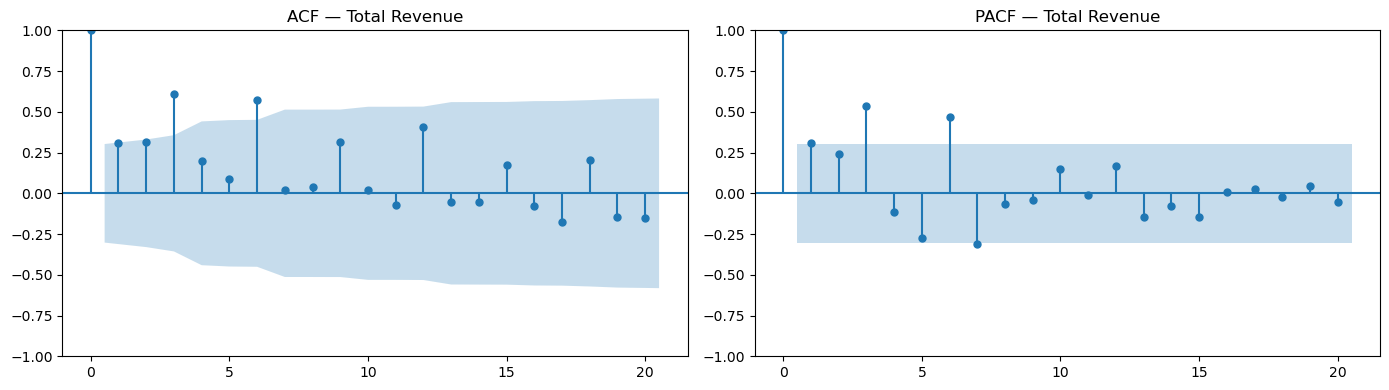

In [ ]:
##ACF / PACF in general 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(total_revenue['Revenue'], lags=20, ax=axes[0], title='ACF — Total Revenue')
plot_pacf(total_revenue['Revenue'], lags=20, ax=axes[1], title='PACF — Total Revenue')
plt.tight_layout()
plt.show()

ACF (left)

Lag 1 is significant and positive (~0.30) — the series has meaningful short-term autocorrelation, meaning last period's revenue is a useful predictor of this period's. This is expected and healthy.
Lag 6 spikes strongly (~0.60) and lag 12 spikes again (~0.55) — this is the clearest confirmation yet of the bimodal seasonal pattern you saw in the boxplot. Revenue 6 periods ago and 12 periods ago are strongly correlated with today's value. This is your seasonal signature.
The slow decay of the ACF rather than a sharp cutoff indicates the series is non-stationary — the trend is creating persistent autocorrelation that extends many lags out. This confirms what the STL trend showed — you need to account for the trend before or within your model.
Negative values appearing after lag 13–14 are typical of a series with a strong seasonal cycle — you're seeing the "opposite phase" of the seasonal pattern.

PACF (right)

Significant spikes at lags 1, 2, and 6 — after controlling for intermediate lags, these are the direct predictors.
The spike at lag 6 (~0.48) in the PACF is particularly important — it directly confirms a 6-period seasonal cycle that isn't just inherited from shorter lags.
After lag 6, the PACF drops into the confidence band — meaning lags beyond 6 don't add much direct predictive power once you've accounted for lags 1, 2, and 6.

What this means for model specification:

If using SARIMA, a reasonable starting point is SARIMA(2,1,0)(1,1,0)[6] or (1,1,0)(1,1,0)[12] — the non-seasonal part needs at least AR(2) based on PACF lags 1 and 2, and the seasonal part needs period 6 or 12.
If using Prophet, set seasonality_mode to test both additive and multiplicative, and add a custom 6-period Fourier seasonality on top of the default annual one.
If using LightGBM, include lag features at t-1, t-2, and t-6 as a minimum — those are your three most important lag predictors based on the PACF.
The confidence bands widen significantly at higher lags due to the small sample (42 observations) — treat anything beyond lag 10 with caution, the estimates are unreliable there.

Overall ACF/PACF summary for your pipeline:
The series has AR(2) short-term structure plus a strong seasonal component at period 6 (and harmonically at 12). It is non-stationary in levels. Any model that ignores either the trend or the 6-period seasonality will leave significant predictable variance on the table.

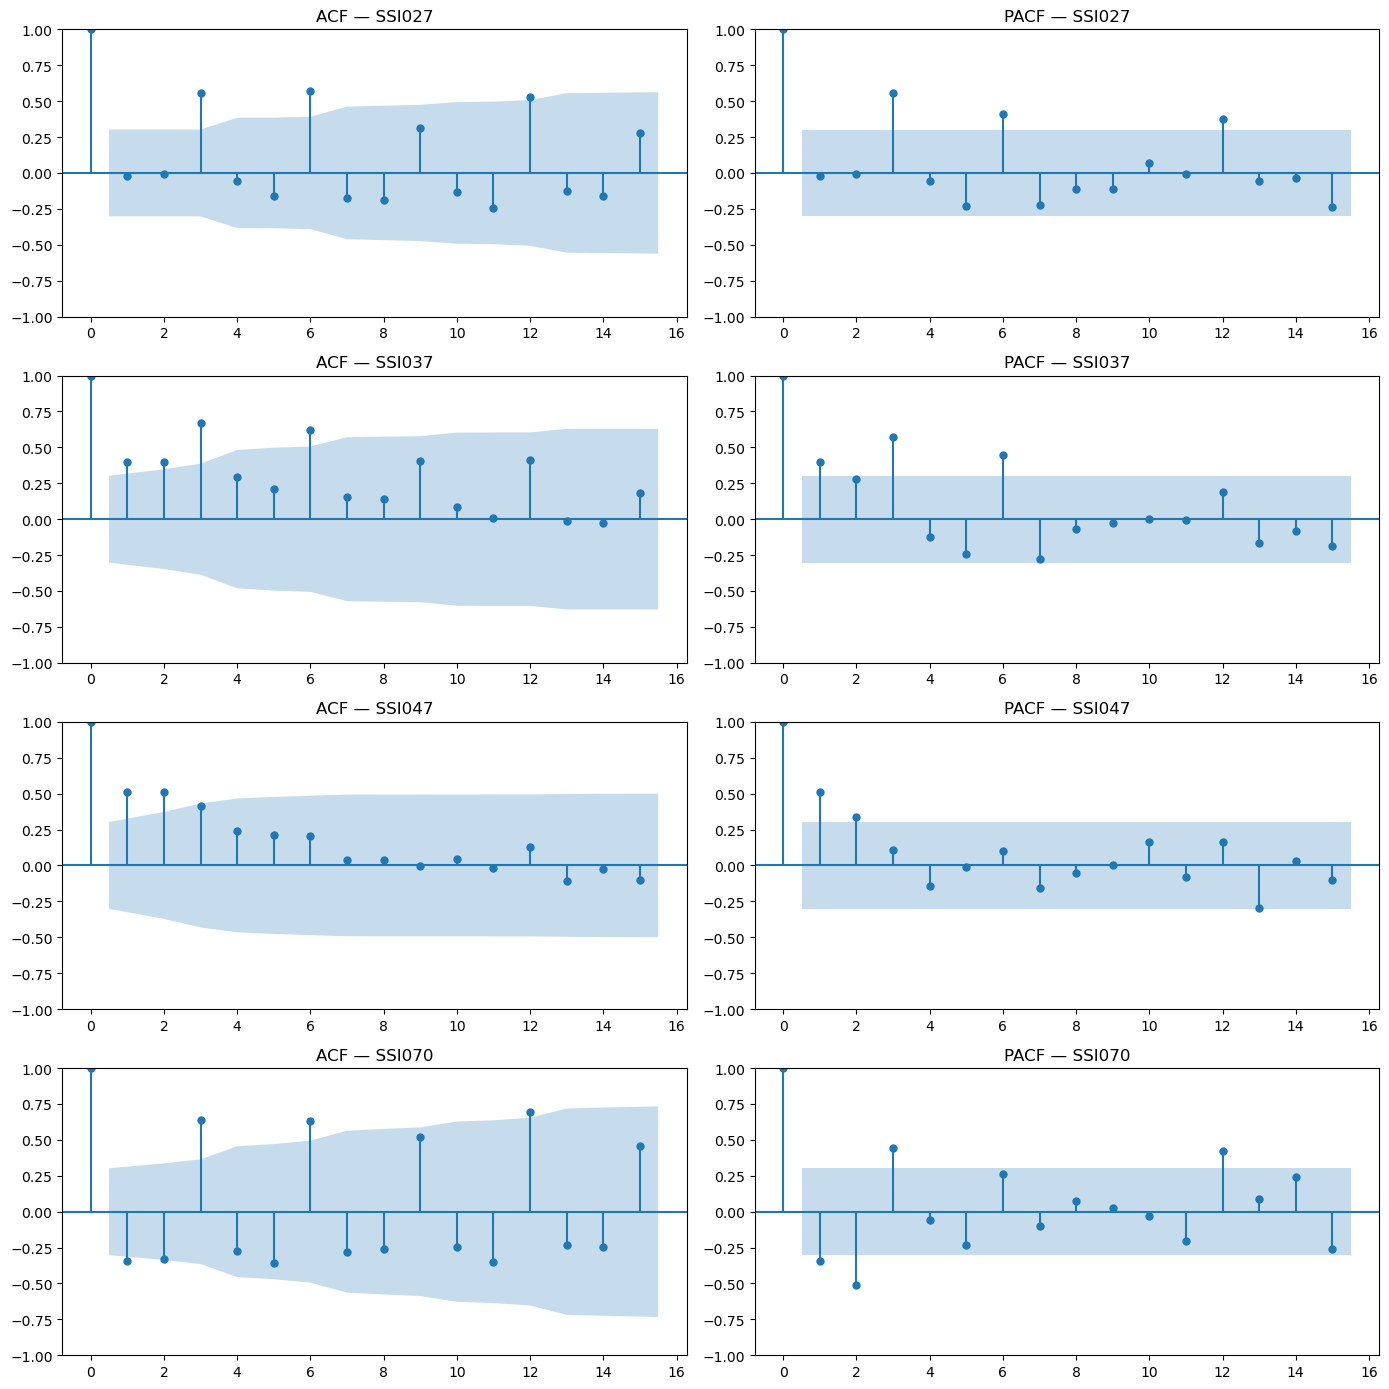

In [ ]:
##ACF / PACF per Business Unit
bu_data = df_merged.groupby(['Business_Unit', 'Period'])['Revenue'].sum().reset_index()

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for i, unit in enumerate(sorted(bu_data['Business_Unit'].unique())):
    data = bu_data[bu_data['Business_Unit'] == unit].sort_values('Period')['Revenue']
    plot_acf(data.values, lags=15, ax=axes[i][0], title=f'ACF — {unit}')
    plot_pacf(data.values, lags=15, ax=axes[i][1], title=f'PACF — {unit}')
plt.tight_layout()
plt.show()

SSI027

ACF shows clear spikes at lags 3, 6, and 12 — the same bimodal seasonal signature as the World level, which makes sense since SSI027 is one of the larger BUs.
PACF has significant spikes at lags 1 and 6 only — simpler AR structure than the World level, suggesting SARIMA(1,1,0)(1,1,0)[6] as a starting point.
Confidence bands are relatively tight — the autocorrelation estimates are reasonably reliable for this BU.

SSI037

ACF decays slowly and remains positive for many lags — classic non-stationary trending series signature, even stronger than what we saw at World level. The trend in SSI037 is so dominant it's bleeding into the autocorrelation structure.
PACF has significant spikes at lags 1, 2, and 6 — similar structure to the World level.
The slow ACF decay is a strong signal to apply first differencing before fitting any ARIMA-type model, or to let Prophet handle the trend natively. Don't fit a stationary model to this series.

SSI047

ACF drops off relatively quickly after lag 1–2 with modest spikes at lags 3 and 6 — the weakest seasonal autocorrelation of all four BUs, consistent with what we saw in the STL where its seasonal component was irregular.
PACF shows only lags 1 and 2 as clearly significant — suggests a simple AR(2) structure after detrending, with only weak seasonality to model.
This BU may actually forecast better with a trend model plus AR(2) residuals than with a full seasonal model.

SSI070

The most unusual pattern — ACF shows strong negative spikes at lags 2 and 8, and positive spikes at lags 3 and 12. This alternating positive/negative pattern in the ACF is a signature of a series that oscillates sharply, which matches the high volatility we saw in its time plot.
PACF has a very large negative spike at lag 2 (~-0.55) which is outside the confidence band — suggesting a MA component rather than pure AR. An ARIMA with a moving average term may fit better for SSI070 than a pure AR model.
Combined with the structural break in its trend, SSI070 remains the most problematic BU. Given all the evidence, seriously consider fitting it on periods 20–42 only and using a simpler model like ETS.

Cross-BU takeaways for modeling:

The lag-6 seasonal spike appears in SSI027 and SSI037 but is weaker in SSI047 and absent as a clean signal in SSI070 — meaning the bimodal seasonality is driven primarily by the two larger BUs and may not be a universal property of the hierarchy.
Fitting a single seasonal period assumption across all BUs would be a mistake — SSI047 and SSI070 need different specifications.
This further reinforces fitting separate models per BU rather than a pooled approach at this level.

c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\martr\One

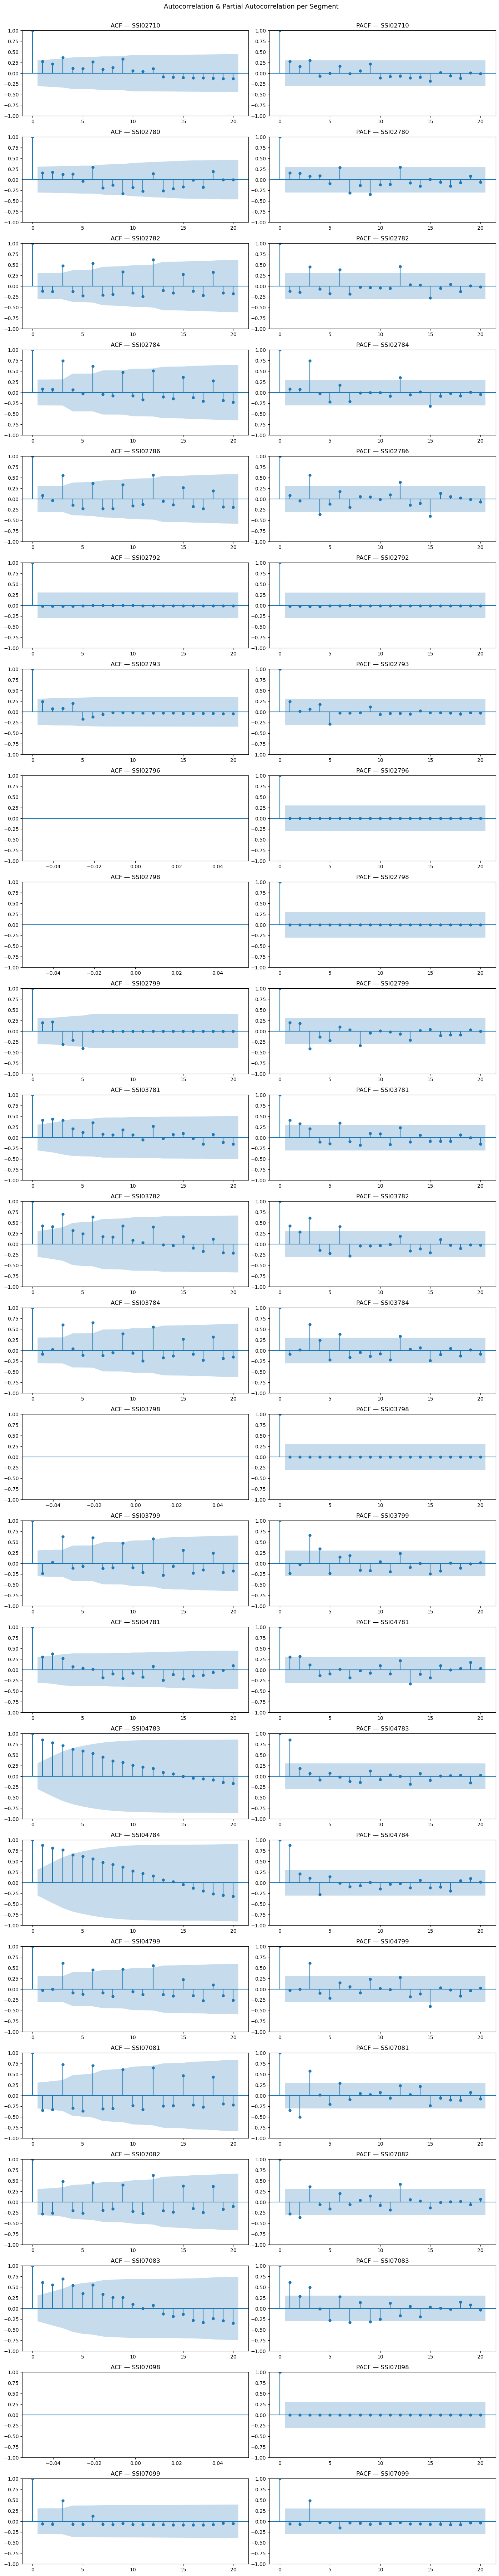

In [ ]:
#ACF / PACF per segment
seg_data = df_merged.groupby(['Segment', 'Period'])['Revenue'].sum().reset_index()
segments = sorted(seg_data['Segment'].unique())

fig, axes = plt.subplots(len(segments), 2, figsize=(14, len(segments) * 3))
for i, seg in enumerate(segments):
    series = seg_data[seg_data['Segment'] == seg].sort_values('Period')['Revenue']
    plot_acf(series, lags=20, ax=axes[i, 0], title=f'ACF — {seg}')
    plot_pacf(series, lags=20, ax=axes[i, 1], title=f'PACF — {seg}')
plt.suptitle('Autocorrelation & Partial Autocorrelation per Segment', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()


#### 3.2.7. Stationary test on all levels

In [ ]:
print("=== ADF Test Results (p < 0.05 = stationary) ===\n")

print("TOTAL REVENUE:")
p = adfuller(total_revenue['Revenue'])[1]
print(f"  Revenue: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}\n")

print("BUSINESS UNITS:")
for unit in sorted(bu_data['Business_Unit'].unique()):
    data = bu_data[bu_data['Business_Unit'] == unit].sort_values('Period')['Revenue']
    p = adfuller(data)[1]
    print(f"  {unit}: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}")

print("\nSEGMENTS:")
seg_data = df_merged.groupby(['Segment', 'Period'])['Revenue'].sum().reset_index()
for seg in sorted(seg_data['Segment'].unique()):
    data = seg_data[seg_data['Segment'] == seg].sort_values('Period')['Revenue']
    if data.nunique() < 2:
        print(f"  {seg}: SKIPPED (constant series)")
        continue
    p = adfuller(data)[1]
    print(f"  {seg}: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}")

=== ADF Test Results (p < 0.05 = stationary) ===

TOTAL REVENUE:
  Revenue: p = 0.6016 → NON-STATIONARY

BUSINESS UNITS:
  SSI027: p = 0.2766 → NON-STATIONARY
  SSI037: p = 0.7132 → NON-STATIONARY
  SSI047: p = 0.0084 → stationary
  SSI070: p = 0.1884 → NON-STATIONARY

SEGMENTS:
  SSI02710: p = 0.9068 → NON-STATIONARY
  SSI02780: p = 0.0189 → stationary
  SSI02782: p = 0.2017 → NON-STATIONARY
  SSI02784: p = 0.3354 → NON-STATIONARY
  SSI02786: p = 0.0270 → stationary
  SSI02792: p = 0.0405 → stationary
  SSI02793: p = 0.0002 → stationary
  SSI02796: SKIPPED (constant series)
  SSI02798: SKIPPED (constant series)
  SSI02799: p = 0.0002 → stationary
  SSI03781: p = 0.9879 → NON-STATIONARY
  SSI03782: p = 0.6993 → NON-STATIONARY
  SSI03784: p = 0.6776 → NON-STATIONARY
  SSI03798: SKIPPED (constant series)
  SSI03799: p = 0.5871 → NON-STATIONARY
  SSI04781: p = 0.0001 → stationary
  SSI04783: p = 0.8978 → NON-STATIONARY
  SSI04784: p = 0.8889 → NON-STATIONARY
  SSI04799: p = 0.6042 → NON-S

Overall stationarity summary

The vast majority of series are non-stationary — this is consistent and expected given the upward trends visible throughout the EDA. First differencing or explicit trend modeling is required almost universally.
4 segments were skipped as constant (SSI02796, SSI02798, SSI03798, SSI07098) — these should be formally excluded from your modeling pipeline now.

The "stationary" results need careful interpretation
Not all stationary results mean the same thing. There are three distinct reasons a series passes ADF here:

Genuinely stationary with cyclical behavior — SSI02780, SSI02786, SSI07082 fit this category based on their time plots. These are the noisy, mean-reverting segments you saw earlier. Stationary here is real and meaningful.
Stationary because the series is near-constant or broken — SSI02792, SSI02793, SSI02799 are the structurally broken/near-zero segments. ADF calls a flatline stationary, which is technically correct but useless for forecasting. Treat these separately.
Suspicious stationarity despite visible trend — SSI04781 has p = 0.0001 which is very strongly stationary, yet visually it appeared to have a trend. With only 42 observations ADF can give misleading results, and a structural break mid-series can actually make ADF falsely reject non-stationarity. Always cross-check with the time plot.

Segment groupings for your pipeline
Based on everything from the EDA combined:
Non-stationary trending segments — need differencing or trend modeling: SSI02710, SSI02782, SSI02784, SSI03781, SSI03782, SSI03784, SSI03799, SSI04783, SSI04784, SSI04799, SSI07081, SSI07083, SSI07099
Stationary forecastable segments — can model in levels: SSI02780, SSI02786, SSI07082
Structurally broken / near-zero — handle separately or exclude: SSI02792, SSI02793, SSI02799, SSI02796, SSI02798, SSI03798, SSI07098

#### 3.2.8. Revenue distribution and skew check

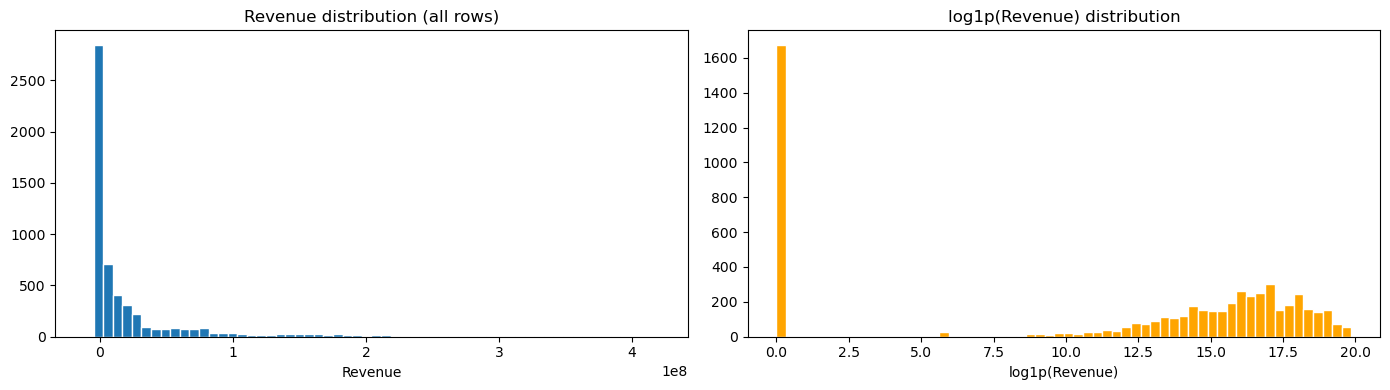

Skewness (raw):        3.258
Skewness (log1p):      -0.663
Negative revenue rows: 33


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_merged['Revenue'], bins=60, edgecolor='white')
axes[0].set_title('Revenue distribution (all rows)')
axes[0].set_xlabel('Revenue')

axes[1].hist(np.log1p(df_merged['Revenue'].clip(lower=0)), bins=60, 
             edgecolor='white', color='orange')
axes[1].set_title('log1p(Revenue) distribution')
axes[1].set_xlabel('log1p(Revenue)')

plt.tight_layout()
plt.show()

print(f"Skewness (raw):        {df_merged['Revenue'].skew():.3f}")
print(f"Skewness (log1p):      {np.log1p(df_merged['Revenue'].clip(lower=0)).skew():.3f}")
print(f"Negative revenue rows: {(df_merged['Revenue'] < 0).sum()}")

Raw distribution (left)

- Extremely right-skewed with a massive spike at zero — over 2,800 rows have near-zero revenue. This is the direct consequence of your full grid expansion — all those (period, subsegment) combinations that didn't exist in the original data got filled with zero.
- The actual non-zero revenue values form a long tail stretching to ~4×10⁸, but they're barely visible because the zero spike dominates the chart.
- This distribution is not meaningful to model directly — you can't log-transform, normalize, or fit a standard regression to a distribution that's 50%+ zeros.

Log1p distribution (right)

- The giant bar at 0 on the left confirms the zero-inflation problem visually — roughly 1,600+ rows are true zeros even after log transformation.
- The right portion shows a roughly bell-shaped distribution centered around 15–18 on the log scale, which corresponds to revenues in the range of ~3M to ~65M EUR. This is the healthy part of your data and it looks well-behaved once you separate it from the zeros.
- The gap between 0 and ~5 on the log scale is notable — there are very few small positive values. Revenue is either zero or meaningfully large, which is typical of B2B industrial sales where orders come in lumps.

## 4. Data Preparation

### 4.1. Split Train/Validation Datasets

In [165]:
# STEP 1 — Aggregate to Segment level (middle-out)

seg_data = (
    df_merged
    .groupby(['Segment', 'Period', 'Date'], as_index=False)
    .agg({
        'Revenue': 'sum',
        **{col: 'first' for col in df_merged.columns 
           if col not in ['Segment', 'Period', 'Date', 'Revenue']}
    })
    .sort_values(['Segment', 'Period'])
    .reset_index(drop=True)
)

print("Segment-level data shape:", seg_data.shape)
seg_data.head()

Segment-level data shape: (1008, 86)


,Segment,Period,Date,Revenue,Business_Unit,Subsegment,Biz_Desc,Orders,China_Core_Inflation_Rate,China_Exports,...,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Start_Period,End_Period,Subseg_Count,Is_Direct
0,SSI02710,1,2021-04-01,-390277,SSI027,SSI02710,SSI,0,0.7,263.09,...,2247.8,16.1,0.1,4.2,0.25,6900.0,1,36,5,False
1,SSI02710,2,2021-05-01,334,SSI027,SSI02710,SSI,0,0.9,263.23,...,2247.8,15.3,0.9,5.0,0.25,7200.0,1,36,5,False
2,SSI02710,3,2021-06-01,334,SSI027,SSI02710,SSI,0,0.9,280.30,...,2275.1,8.7,0.5,5.4,0.25,7100.0,1,36,5,False
3,SSI02710,4,2021-07-01,1811758,SSI027,SSI02710,SSI,0,1.3,281.28,...,2275.1,5.3,0.4,5.4,0.25,7500.0,1,36,5,False
4,SSI02710,5,2021-08-01,80112,SSI027,SSI02710,SSI,0,1.2,293.17,...,2275.1,4.3,0.0,5.3,0.25,7500.0,1,36,5,False


In [166]:
# STEP 2 — Time-based split

seg_train = seg_data[seg_data['Period'] <= 36].copy()
seg_val   = seg_data[(seg_data['Period'] >= 37) & (seg_data['Period'] <= 42)].copy()

print("Train periods:", seg_train['Period'].min(), "to", seg_train['Period'].max())
print("Val periods:",   seg_val['Period'].min(),   "to", seg_val['Period'].max())

Train periods: 1 to 36
Val periods: 37 to 42


### 4.2. Feature Engineering

In [167]:
# STEP 3 — Combine ONLY for feature engineering

df_all = pd.concat([seg_train, seg_val], axis=0)
df_all = df_all.sort_values(['Segment', 'Period']).reset_index(drop=True)

In [168]:
# STEP 4.1 — Lag features

for lag in [1, 3, 6, 12]:
    df_all[f'lag_{lag}'] = df_all.groupby('Segment')['Revenue'].shift(lag)

print("Lag features created")

Lag features created


In [169]:
# STEP 4.2 — Rolling mean features 

for window in [3, 6, 12]:
    df_all[f'rolling_mean_{window}'] = (
        df_all.groupby('Segment')['Revenue']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
    )

print("Rolling mean features created")

Rolling mean features created


In [170]:
# STEP 4.3 — Delta features (fixed)
# delta between lag_1 and lag_2 (both past values — no leakage)
df_all['delta_1']  = df_all.groupby('Segment')['Revenue'].shift(1) - df_all.groupby('Segment')['Revenue'].shift(2)
df_all['delta_12'] = df_all.groupby('Segment')['Revenue'].shift(1) - df_all.groupby('Segment')['Revenue'].shift(13)

print("Delta features created")

Delta features created


In [171]:
# STEP 4.4 — Calendar features

df_all['Date'] = pd.to_datetime(df_all['Date'])

df_all['Month']   = df_all['Date'].dt.month
df_all['Quarter'] = df_all['Date'].dt.quarter

print("Calendar features created")

Calendar features created


In [172]:
# STEP 4.5 — Cyclical encoding of month

df_all['Month_sin'] = np.sin(2 * np.pi * df_all['Month'] / 12)
df_all['Month_cos'] = np.cos(2 * np.pi * df_all['Month'] / 12)

print("Cyclical features created")

Cyclical features created


In [173]:
# STEP 4.6 — Trend feature

df_all['trend'] = df_all['Period']

print("Trend feature created")

Trend feature created


In [174]:
# STEP 4.7 — Event features
# period 11-14 = Ukraine war start (Feb 2022)
# period 15-21 = peak inflation and energy crisis (mid to late 2022)
# period 22-33 = post-crisis normalisation (2023)
df_all['is_war_period']    = ((df_all['Period'] >= 11) & (df_all['Period'] <= 14)).astype(int)
df_all['is_energy_crisis'] = ((df_all['Period'] >= 15) & (df_all['Period'] <= 21)).astype(int)
df_all['is_normalisation'] = ((df_all['Period'] >= 22) & (df_all['Period'] <= 33)).astype(int)

print("Event features created")

Event features created


In [175]:
df_all.head()

,Segment,Period,Date,Revenue,Business_Unit,Subsegment,Biz_Desc,Orders,China_Core_Inflation_Rate,China_Exports,...,delta_1,delta_12,Month,Quarter,Month_sin,Month_cos,trend,is_war_period,is_energy_crisis,is_normalisation
0,SSI02710,1,2021-04-01,-390277,SSI027,SSI02710,SSI,0,0.7,263.09,...,NaN,NaN,4,2,8.660254e-01,-0.500000,1,0,0,0
1,SSI02710,2,2021-05-01,334,SSI027,SSI02710,SSI,0,0.9,263.23,...,NaN,NaN,5,2,5.000000e-01,-0.866025,2,0,0,0
2,SSI02710,3,2021-06-01,334,SSI027,SSI02710,SSI,0,0.9,280.30,...,390611.0,NaN,6,2,1.224647e-16,-1.000000,3,0,0,0
3,SSI02710,4,2021-07-01,1811758,SSI027,SSI02710,SSI,0,1.3,281.28,...,0.0,NaN,7,3,-5.000000e-01,-0.866025,4,0,0,0
4,SSI02710,5,2021-08-01,80112,SSI027,SSI02710,SSI,0,1.2,293.17,...,1811424.0,NaN,8,3,-8.660254e-01,-0.500000,5,0,0,0


In [176]:
# STEP 5 — Split back after feature engineering

train_final = df_all[df_all['Period'] <= 36].copy()
val_final   = df_all[(df_all['Period'] >= 37) & (df_all['Period'] <= 42)].copy()

In [177]:
# STEP 6 — Define X and y

X_train = train_final.drop(columns=['Revenue'])
y_train = train_final['Revenue']

X_val = val_final.drop(columns=['Revenue'])
y_val = val_final['Revenue']

print("Final shapes:")
print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("y_train:", y_train.shape)
print("y_val:",   y_val.shape)

Final shapes:
X_train: (864, 102)
X_val: (144, 102)
y_train: (864,)
y_val: (144,)


In [178]:
X_train.head()

,Segment,Period,Date,Business_Unit,Subsegment,Biz_Desc,Orders,China_Core_Inflation_Rate,China_Exports,China_GDP,...,delta_1,delta_12,Month,Quarter,Month_sin,Month_cos,trend,is_war_period,is_energy_crisis,is_normalisation
0,SSI02710,1,2021-04-01,SSI027,SSI02710,SSI,0,0.7,263.09,14996.41,...,NaN,NaN,4,2,8.660254e-01,-0.500000,1,0,0,0
1,SSI02710,2,2021-05-01,SSI027,SSI02710,SSI,0,0.9,263.23,14996.41,...,NaN,NaN,5,2,5.000000e-01,-0.866025,2,0,0,0
2,SSI02710,3,2021-06-01,SSI027,SSI02710,SSI,0,0.9,280.30,14996.41,...,390611.0,NaN,6,2,1.224647e-16,-1.000000,3,0,0,0
3,SSI02710,4,2021-07-01,SSI027,SSI02710,SSI,0,1.3,281.28,14996.41,...,0.0,NaN,7,3,-5.000000e-01,-0.866025,4,0,0,0
4,SSI02710,5,2021-08-01,SSI027,SSI02710,SSI,0,1.2,293.17,14996.41,...,1811424.0,NaN,8,3,-8.660254e-01,-0.500000,5,0,0,0


In [179]:
#checking number of missing values
X_train.isna().sum()

Segment                                       0
Period                                        0
Date                                          0
Business_Unit                                 0
Subsegment                                    0
Biz_Desc                                    192
Orders                                        0
China_Core_Inflation_Rate                     0
China_Exports                                 0
China_GDP                                     0
China_GDP_from_Construction                   0
China_GDP_from_Manufacturing                  0
China_Industrial_Production                   0
China_Industrial_Production_Mom               0
China_Inflation_Rate                          0
China_Interest_Rate                           0
China_Steel_Production                        0
France_Core_Inflation_Rate                    0
France_Exports                                0
France_GDP                                    0
France_GDP_from_Construction            

### 4.3. Feature Selection

**Features to drop since the beggining**:
- *Biz_Desc*: Constant variable- all observations have the same- Siemens
- *Orders*: It cannot be used as an estimator because the test dataset does not have information about it. 

In [180]:
# Droping the columns
'''columns_to_drop = ["Orders", "Biz_Desc"]
X_train = X_train.drop(columns=columns_to_drop)
X_val = X_val.drop(columns=columns_to_drop)'''

'columns_to_drop = ["Orders", "Biz_Desc"]\nX_train = X_train.drop(columns=columns_to_drop)\nX_val = X_val.drop(columns=columns_to_drop)'

#### 4.3.1. Filter Methods

In [181]:
# Option 2: Just get a list of all column names
all_columns = X_train.columns.tolist()
print(all_columns)

['Segment', 'Period', 'Date', 'Business_Unit', 'Subsegment', 'Biz_Desc', 'Orders', 'China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'France_Industrial_Production', 'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Germany_Industrial_Production', 'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Italy_In

In [182]:
# ── filter method 1: variance check ──────────────────────────────────────────
# features with near-zero variance carry no information
# compute on X_train only

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

variances = X_train[numeric_cols].var().sort_values()

print("Features with lowest variance:")
print(variances.head(15))

# flag features with variance below threshold
low_var_threshold = 1e6  # adjust based on your revenue scale
low_var_features  = variances[variances < low_var_threshold].index.tolist()
print(f"\nFeatures with variance < {low_var_threshold}: {low_var_features}")

Features with lowest variance:
Japan_Interest_Rate                         0.001081
China_Interest_Rate                         0.019397
China_Core_Inflation_Rate                   0.066466
China_Industrial_Production_Mom             0.075774
is_war_period                               0.098880
is_energy_crisis                            0.156817
is_normalisation                            0.222480
Switzerland_Core_Inflation_Rate             0.341591
United_States_Industrial_Production_Mom     0.363963
Month_cos                                   0.500579
Month_sin                                   0.500579
United_Kingdom_Industrial_Production_Mom    0.760572
Switzerland_Inflation_Rate                  0.890004
China_Inflation_Rate                        0.964102
United_States_Core_Inflation_Rate           0.981692
dtype: float64

Features with variance < 1000000.0: ['Japan_Interest_Rate', 'China_Interest_Rate', 'China_Core_Inflation_Rate', 'China_Industrial_Production_Mom', 'is_war_per

Feature correlation with Revenue (top 20):
lag_3                            0.990468
rolling_mean_3                   0.988974
lag_12                           0.988752
rolling_mean_6                   0.988613
lag_6                            0.988328
rolling_mean_12                  0.987541
lag_1                            0.977032
delta_12                         0.544548
Subseg_Count                     0.504549
End_Period                       0.209272
Orders                           0.125816
Switzerland_GDP                  0.062431
United_States_GDP                0.060761
Italy_GDP_from_Construction      0.059772
trend                            0.059535
Period                           0.059535
United_Kingdom_GDP               0.059318
China_Interest_Rate              0.057584
Italy_GDP                        0.055386
Germany_GDP_from_Construction    0.054101


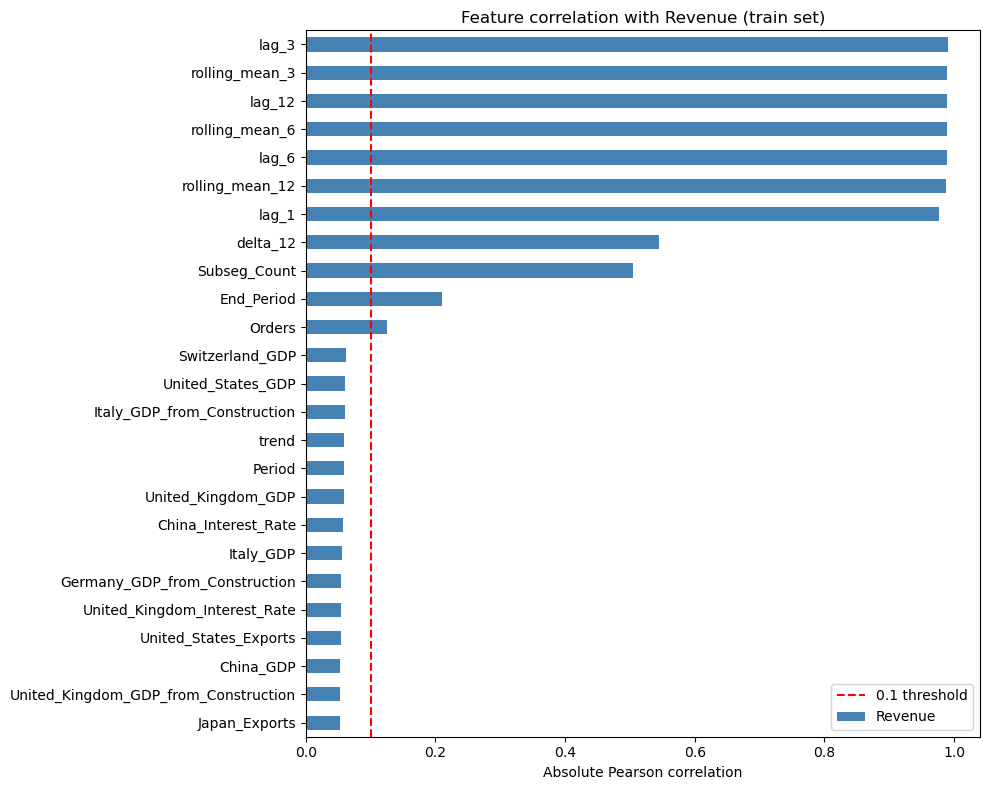


Features with correlation < 0.1: ['Switzerland_GDP', 'United_States_GDP', 'Italy_GDP_from_Construction', 'trend', 'Period', 'United_Kingdom_GDP', 'China_Interest_Rate', 'Italy_GDP', 'Germany_GDP_from_Construction', 'United_Kingdom_Interest_Rate', 'United_States_Exports', 'China_GDP', 'United_Kingdom_GDP_from_Construction', 'Japan_Exports', 'United_States_Interest_Rate', 'Italy_Interest_Rate', 'France_Interest_Rate', 'Germany_Interest_Rate', 'Switzerland_Interest_Rate', 'Germany_GDP', 'United_States_Industrial_Production', 'France_Exports', 'Japan_GDP_from_Construction', 'Japan_GDP', 'Japan_GDP_from_Manufacturing', 'Switzerland_Industrial_Production', 'France_GDP', 'Japan_Inflation_Rate', 'delta_1', 'Germany_Industrial_Production', 'Germany_Exports', 'Italy_Exports', 'Italy_GDP_from_Manufacturing', 'Japan_Steel_Production', 'Japan_Core_Inflation_Rate', 'United_Kingdom_Exports', 'Japan_Industrial_Production', 'Italy_Industrial_Production', 'United_States_Steel_Production', 'United_Kingd

In [183]:
# ── filter method 2: correlation with target ──────────────────────────────────
# compute correlation of each feature with Revenue
# using X_train joined with y_train

train_with_target = X_train.copy()
train_with_target['Revenue'] = y_train.values

correlations = (
    train_with_target[numeric_cols + ['Revenue']]
    .corr()['Revenue']
    .drop('Revenue')
    .abs()
    .sort_values(ascending=False)
)

print("Feature correlation with Revenue (top 20):")
print(correlations.head(20).to_string())

# visualise
plt.figure(figsize=(10, 8))
correlations.head(25).plot(kind='barh', color='steelblue')
plt.axvline(0.1, color='red', linestyle='--', label='0.1 threshold')
plt.title('Feature correlation with Revenue (train set)')
plt.xlabel('Absolute Pearson correlation')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

# flag low correlation features
low_corr_features = correlations[correlations < 0.1].index.tolist()
print(f"\nFeatures with correlation < 0.1: {low_corr_features}")

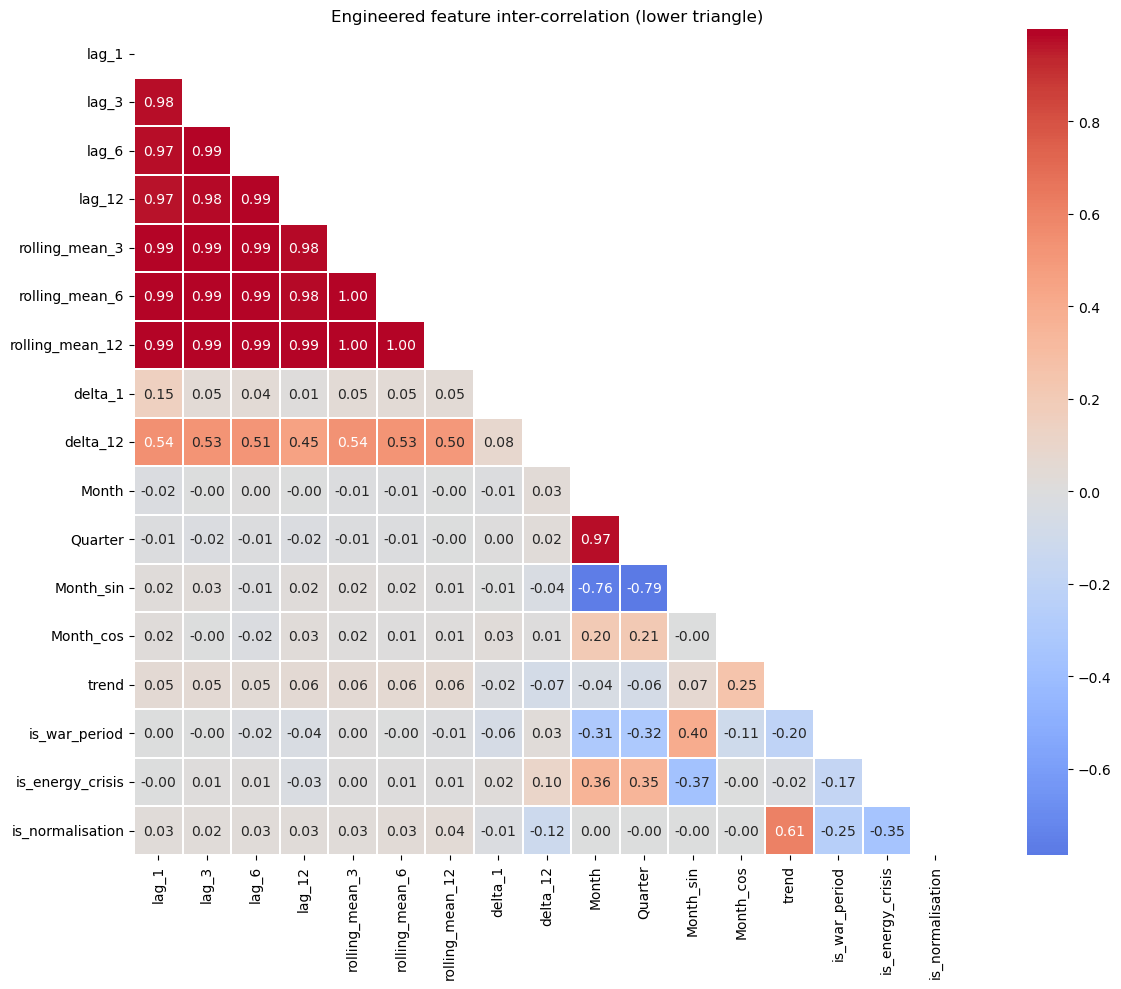

In [189]:
# ── filter method 3: multicollinearity check — engineered features ────────────
key_features = [c for c in numeric_cols if any(c.startswith(x) for x in
                ['lag', 'rolling', 'delta', 'Month', 'Quarter', 'trend',
                 'is_war', 'is_energy', 'is_normal', 'Month_sin', 'Month_cos'])]

corr_matrix = X_train[key_features].corr()

# create mask for upper triangle — shows only lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm', center=0, annot=True, fmt='.2f',
    linewidths=0.3, square=True
)
plt.title('Engineered feature inter-correlation (lower triangle)')
plt.tight_layout()
plt.show()

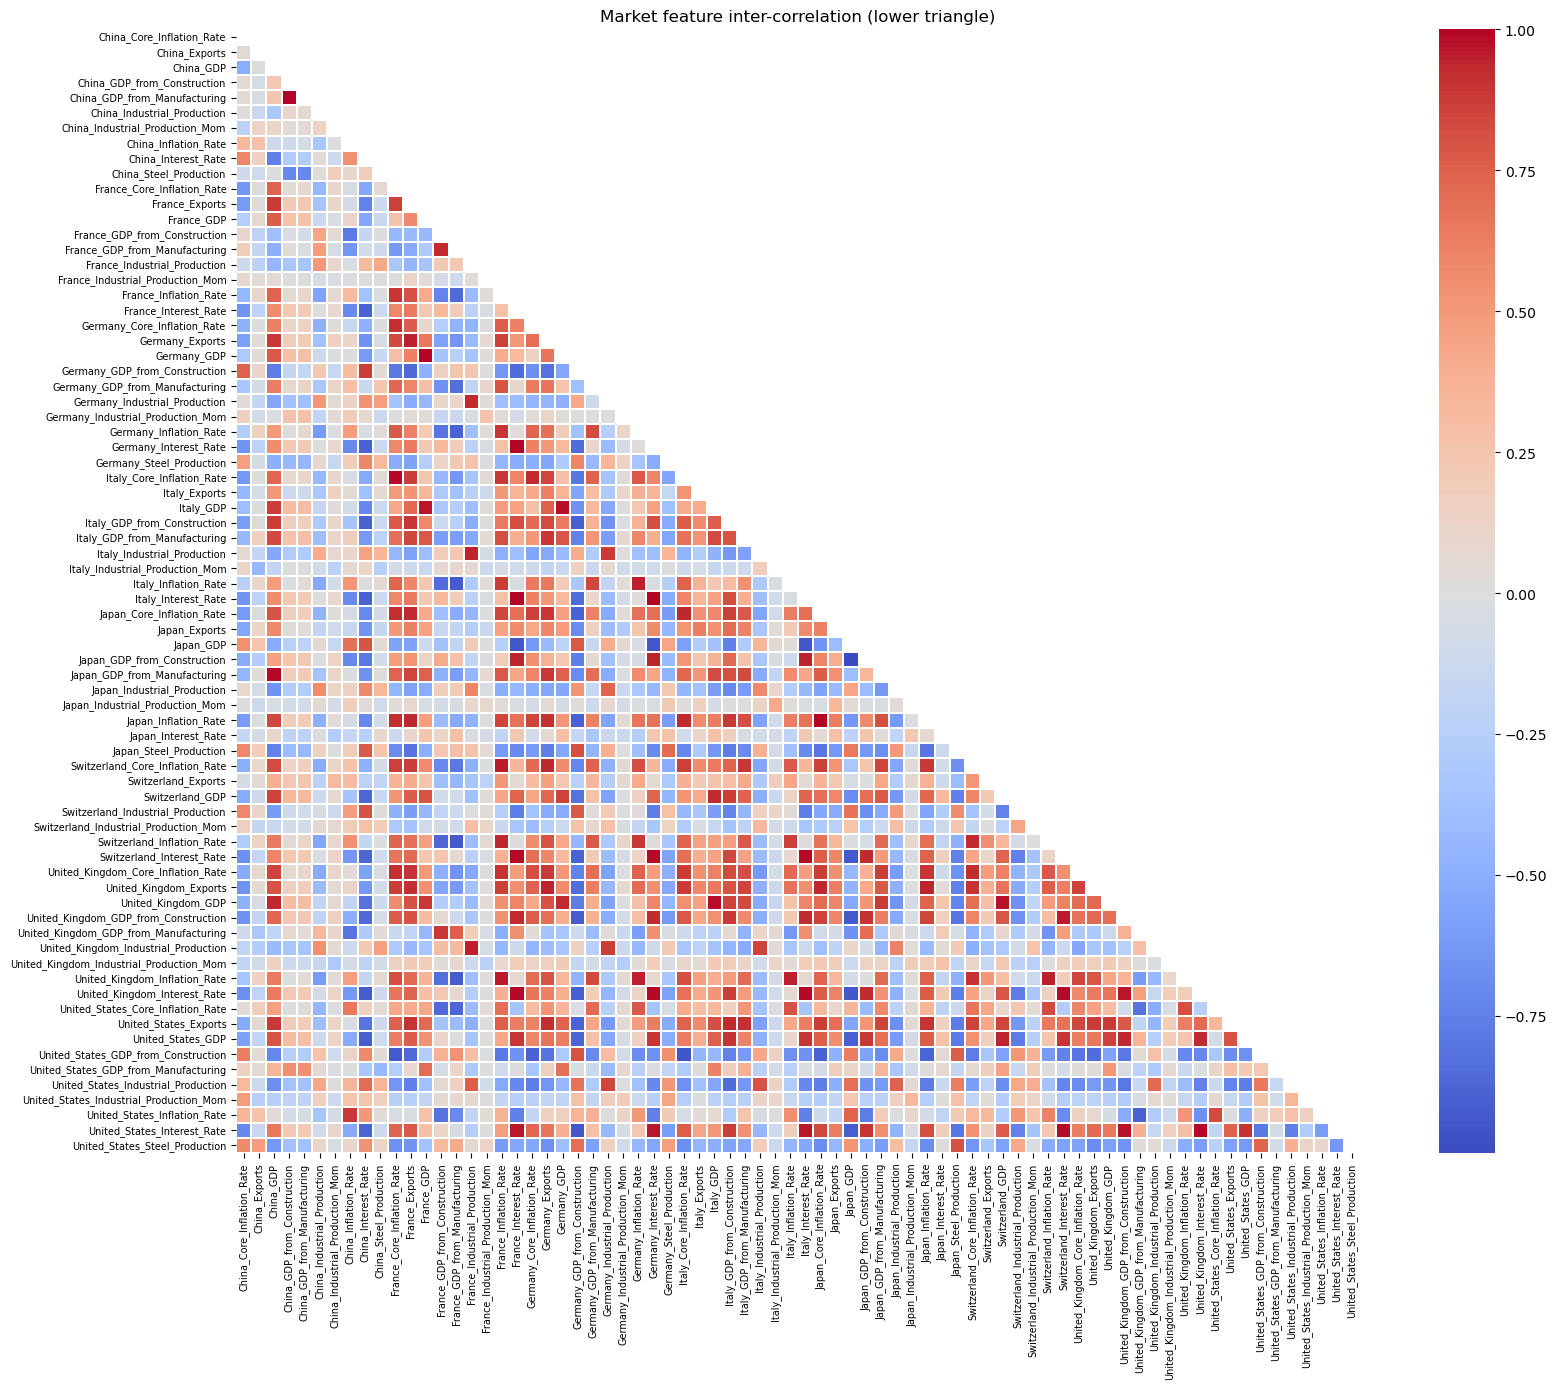

Highly correlated market pairs (>0.80): 266 pairs found
  China_GDP  vs  France_Exports:  0.876
  China_GDP  vs  Germany_Exports:  0.886
  China_GDP  vs  Italy_GDP:  0.868
  China_GDP  vs  Italy_GDP_from_Construction:  0.871
  China_GDP  vs  Italy_GDP_from_Manufacturing:  0.832
  China_GDP  vs  Japan_GDP_from_Manufacturing:  0.987
  China_GDP  vs  Japan_Inflation_Rate:  0.84
  China_GDP  vs  Switzerland_Core_Inflation_Rate:  0.823
  China_GDP  vs  Switzerland_GDP:  0.857
  China_GDP  vs  United_Kingdom_Core_Inflation_Rate:  0.858
  China_GDP  vs  United_Kingdom_GDP:  0.93
  China_GDP  vs  United_States_Exports:  0.887
  China_GDP_from_Construction  vs  China_GDP_from_Manufacturing:  0.998
  China_Inflation_Rate  vs  United_Kingdom_GDP_from_Manufacturing:  0.803
  China_Inflation_Rate  vs  United_States_Inflation_Rate:  0.886
  China_Interest_Rate  vs  France_Interest_Rate:  0.889
  China_Interest_Rate  vs  Germany_GDP_from_Construction:  0.873
  China_Interest_Rate  vs  Germany_Interes

In [191]:
# ── filter method 3b: multicollinearity check — market features ───────────────
market_feat_cols = [c for c in numeric_cols if any(c.startswith(x) for x in
                    ['Germany', 'France', 'China', 'Italy', 'Japan',
                     'Switzerland', 'United_Kingdom', 'United_States'])]

corr_market = X_train[market_feat_cols].corr()
mask_market = np.triu(np.ones_like(corr_market, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_market,
    mask=mask_market,
    cmap='coolwarm', center=0,
    linewidths=0.3, square=True,
    xticklabels=True, yticklabels=True
)
plt.title('Market feature inter-correlation (lower triangle)')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# identify highly correlated market pairs (>0.95)
high_corr_market = []
for i in range(len(market_feat_cols)):
    for j in range(i+1, len(market_feat_cols)):
        val = abs(corr_market.loc[market_feat_cols[i], market_feat_cols[j]])
        if val > 0.80:
            high_corr_market.append((market_feat_cols[i], market_feat_cols[j], round(val, 3)))

print(f"Highly correlated market pairs (>0.80): {len(high_corr_market)} pairs found")
for pair in high_corr_market:
    print(f"  {pair[0]}  vs  {pair[1]}:  {pair[2]}")

#### 4.3.2. Embedded Methods

In [188]:
# ── embedded method: lightgbm feature importance ──────────────────────────────
# train a quick lightgbm just to get feature importances
# this tells us which features the model actually finds useful
!pip install lightgbm
import lightgbm as lgb

# drop non-numeric and identifier columns for this check
cols_to_drop = ['Date', 'Segment', 'Business_Unit', 'Subsegment', 'Biz_Desc']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_lgb = X_train.drop(columns=cols_to_drop)
X_val_lgb   = X_val.drop(columns=cols_to_drop)

# fill any remaining NaNs with median (only for importance check)
X_train_lgb = X_train_lgb.fillna(X_train_lgb.median())
X_val_lgb   = X_val_lgb.fillna(X_train_lgb.median())

model_fs = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
model_fs.fit(X_train_lgb, y_train)

importance = pd.Series(
    model_fs.feature_importances_,
    index=X_train_lgb.columns
).sort_values(ascending=False)

print("LightGBM feature importance (top 20):")
print(importance.head(20).to_string())

plt.figure(figsize=(10, 8))
importance.head(20).plot(kind='barh', color='steelblue')
plt.title('LightGBM feature importance — top 20')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# flag features with zero importance
zero_importance = importance[importance == 0].index.tolist()
print(f"\nFeatures with zero importance (candidates to drop): {zero_importance}")

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------------------

ERROR: Could not install packages due to an OSError: [WinError 32] O processo não pode aceder ao ficheiro porque este está a ser utilizado por outro processo: 'C:\\Users\\martr\\AppData\\Local\\Temp\\pip-unpack-n3ak5j5j\\lightgbm-4.6.0-py3-none-win_amd64.whl'
Consider using the `--user` option or check the permissions.



ModuleNotFoundError: No module named 'lightgbm'

Random Forest feature importance (top 20):
rolling_mean_6                              0.365595
rolling_mean_12                             0.353261
rolling_mean_3                              0.178495
lag_3                                       0.050346
Subseg_Count                                0.010824
lag_1                                       0.010248
lag_6                                       0.010015
Orders                                      0.004197
End_Period                                  0.002307
Start_Period                                0.001824
lag_12                                      0.001279
delta_1                                     0.000599
United_Kingdom_Industrial_Production        0.000579
Month_sin                                   0.000514
United_States_GDP_from_Manufacturing        0.000381
China_Industrial_Production_Mom             0.000380
Switzerland_Exports                         0.000359
United_Kingdom_Industrial_Production_Mom    0.000358
Ger

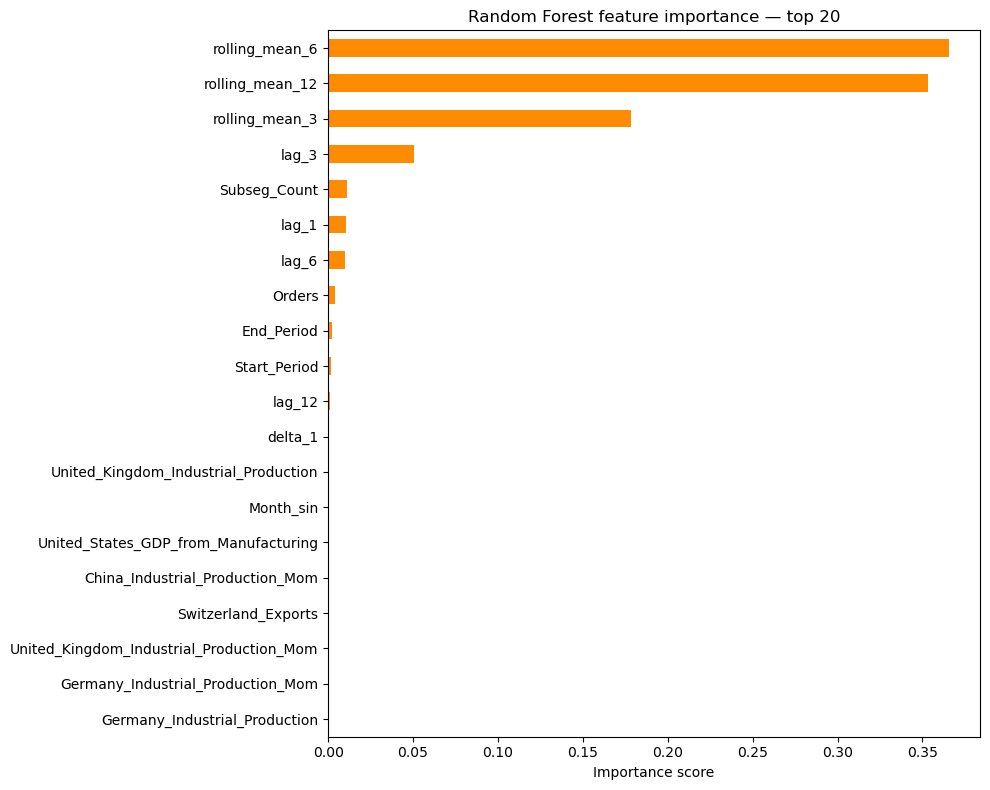

In [192]:
# ── embedded method 2: random forest feature importance ───────────────────────
from sklearn.ensemble import RandomForestRegressor

cols_to_drop_rf = ['Date', 'Segment', 'Business_Unit', 'Subsegment', 'Biz_Desc']
cols_to_drop_rf = [c for c in cols_to_drop_rf if c in X_train.columns]

X_train_rf = X_train.drop(columns=cols_to_drop_rf).copy()
X_train_rf = X_train_rf.fillna(-1)

model_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train_rf, y_train)

importance_rf = pd.Series(
    model_rf.feature_importances_,
    index=X_train_rf.columns
).sort_values(ascending=False)

print("Random Forest feature importance (top 20):")
print(importance_rf.head(20).to_string())

plt.figure(figsize=(10, 8))
importance_rf.head(20).plot(kind='barh', color='darkorange')
plt.title('Random Forest feature importance — top 20')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ── final feature selection decision ─────────────────────────────────────────
# combine insights from all methods above
# drop features that are: low variance AND low correlation AND zero importance

candidates_to_drop = list(set(low_var_features) & set(low_corr_features))
candidates_to_drop += zero_importance
candidates_to_drop  = list(set(candidates_to_drop))

print("Features recommended to drop:")
print(candidates_to_drop)

# apply to X_train and X_val
X_train_selected = X_train.drop(columns=[c for c in candidates_to_drop if c in X_train.columns])
X_val_selected   = X_val.drop(columns=[c for c in candidates_to_drop if c in X_val.columns])

print("\nX_train after selection:", X_train_selected.shape)
print("X_val after selection:",   X_val_selected.shape)